# General structure of the file

This file contains all the interpolations done in this experiment. The general structure is such:
- Variable/Constants & Imports
    contains all imports needed to run the code + some constants such the time characteristic of the muons in different materials
- Function

    Is split into multiple cells:
    - the first contains a couple of functions to unpack data
    - the second contains all functions useful for interpolations

    The function naming scheme is: (double_)exp(_unif)(_pdf) where each parenthesized part can be omitted independently to call a different function

**interpolations** kinda autoexplanatory

- chi square analysis
    Are cells that take a **long time** to process 
    - binning
        change number of bins and reinterpolate to see how the chi square varies

    - cuts
        at the start and at the end cut parts of the dataset and reinterpolate to see if there are points that worsen the interpolation significantly

# Variable/Constants & Imports


In [54]:
import numpy as np
from collections.abc import Callable
from iminuit import Minuit
from iminuit.cost import LeastSquares
from scipy.stats import expon, uniform, chi2
import scipy.stats as stats
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


from plots import plots
from tqdm.notebook import tqdm
from library import dataset_analysis, end , model_function_builder , propagazione_errore


n_bins = 57
N = 9874
TAU_MU = 2.1969811e-6
TAU_C = 2.18e-6
TAU_Al = 0.864e-6
TAU_NaCl = 0.702e-6


n_bins_void = 68
n_bins_na = 64
n_bins_al = 94
n_bins_nf = 80
n_bins_pv = 96

# Functions


## Utilities


In [55]:
def sturges( N: int):
    return int(np.round( 1 + np.log2(N)))


def dataset_splitter(data: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    data = data.T
    discriminator = np.array([bool(i) for i in data[1]])

    data_g = data[0][discriminator]
    data_p = data[0][~discriminator]
    return data_g, data_p



def to_typst_table(minuit_obj, caption="Fit Parameters"):
    """
    Takes an iminuit Minuit object and returns a Typst format table string.
    """
    # Header of the Typst string
    typst_str = f"table(\n" \
                f"  columns: (auto, auto, auto),\n" \
                f"  align: (left, right, right),\n" \
                f"  stroke: 0.5pt + luma(120),\n" \
                f"  fill: (x, y) => if y == 0 {{ luma(240) }} else {{ none }},\n" \
                f"  [*Parameter*], [*Value*], [*Uncertainty*],\n"

    # Loop through parameters and extract data
    for param in minuit_obj.parameters:
        val = minuit_obj.values[param]
        err = minuit_obj.errors[param]
        
        # Add a row to the Typst table
        if val < 1e-3 or val > 1e3:
            typst_str += f"  [{param}], [{val:.4e}], [{err:.4e}],\n"
        else:
            typst_str += f"  [{param}], [{val:.4f}], [{err:.4f}],\n"
    
    typst_str += f")"
    
    if caption:
        typst_str = f"#figure(\n  {typst_str},\n  caption: [{caption}],\n)"
        
    return typst_str


## Models


### CDFs


In [56]:
def normalization( model, min_dataset: int , max_dataset:int) -> float:
    cdf_diff = model.cdf(max_dataset) - model.cdf(min_dataset)
    return float(np.asarray(cdf_diff).item())

def exp( x , N , min , max, A, tau1):
    return N*expon.cdf(x , A , tau1)/normalization(expon( loc = A , scale = tau1) , min , max) 

def exp_unif(x, N , min , max , freq_exp1, tau1, A):
    exp = expon( loc = A , scale = tau1)
    return freq_exp1 * N * exp.cdf(x)/normalization(exp , min , max) + (1-freq_exp1) * N * uniform.cdf(x, min, max)

def double_exp( x , N , min , max , freq_exp1 , tau1 , tau2 , A ):
    exp1 = (expon( loc = A , scale = tau1)) 
    exp2 = expon( loc = A , scale = tau2)
    return freq_exp1 * N * exp1.cdf(x)/normalization( exp1 , min , max) + (1-freq_exp1) * N * exp2.cdf(x)/normalization(exp2, min , max) 

def double_exp_unif( x , N , min , max,  freq_exp , relative_freq , tau1 , tau2 , A ):
    exp1 = (expon( loc = A , scale = tau1)) 
    exp2 = expon( loc = A , scale = tau2)
    return  N * freq_exp * ((1 - relative_freq)* exp1.cdf(x)/normalization( exp1 , min , max) + (relative_freq) * exp2.cdf(x)/normalization(exp2, min , max)) + (1 - freq_exp) * N * (uniform.cdf(x, min, max))



### PDFs


In [57]:
def exp_pdf( x , min , max,  freq, A, tau):
    return freq * expon.pdf(x , A , tau) /normalization(expon( loc = A , scale = tau) , min , max)

def exp_unif_pdf(x, min , max , freq, tau, A):
    exp = expon( loc = A , scale = tau)
    return freq * exp.pdf(x)/normalization(exp , min, max) + (1-freq)* uniform.pdf(x, min, max) # type: ignore

def double_exp_pdf( x , min , max,  freq, tau1 , tau2 , A ):
    exp1 = expon( loc = A , scale = tau1)
    exp2 = expon( loc = A , scale = tau2)
    return freq * (exp1.pdf(x))/normalization(exp1, min, max) + (1-freq) * (exp2.pdf(x))/normalization(exp2, min , max) # type: ignore

def double_exp_unif_pdf( x , min , max,  freq_exp , relative_freq , tau1 , tau2 , A ):
    exp1 = (expon( loc = A , scale = tau1)) 
    exp2 = expon( loc = A , scale = tau2)
    return freq_exp * (( 1 - relative_freq)*exp1.pdf(x)/normalization( exp1 , min , max) + (relative_freq) * exp2.pdf(x)/normalization(exp2, min , max)) + (1 - freq_exp) * (uniform.pdf(x, min, max))


# Dataset


## void


In [58]:
# void datasets
data_0 = np.genfromtxt("Data/timestamp/21_01_2024_17_42.csv", delimiter=',')
data_1 = np.genfromtxt("Data/timestamp/23_01_2026_17_31.csv", delimiter=',')
data_2 = np.genfromtxt("Data/timestamp/29_01_2026_17_20.csv", delimiter=',')
data_3 = np.genfromtxt("Data/timestamp/02_02_2026_17_14.csv", delimiter=',')
data_4 = np.genfromtxt("Data/timestamp/05_02_2026_18_17.csv", delimiter=',')
data_5 = np.genfromtxt("Data/timestamp/11_02_2026_17_52.csv", delimiter=',')
data_6 = np.genfromtxt("Data/timestamp/16_02_2026_12_25.csv", delimiter=',')
data_7 = np.genfromtxt("Data/timestamp/20_02_2026_15_57.csv", delimiter=',')
inv_data_1 = np.genfromtxt("Data/timestamp/inverted_26_02_2026_16_57.csv" , delimiter=',')
mult_data_1 = np.genfromtxt("Data/timestamp/triple_04_03_2026_05_12.csv",delimiter=",")
mult_data_2 = np.genfromtxt("Data/timestamp/triple_06_03_2026_14_12.csv" , delimiter=",")
mult_data_3 = np.genfromtxt("Data/timestamp/triple_delay_16_03_2026_14_17.csv" , delimiter=",")
mult_data_4 = np.genfromtxt("Data/timestamp/triple_delay_20_03_2026_14_27.csv" , delimiter=",")

display(mult_data_1)

data_g_1 , data_p_1 = dataset_splitter( mult_data_1)
data_g_2 , data_p_2 = dataset_splitter( mult_data_2)
data_g_3 , data_p_3 = dataset_splitter( mult_data_3)
data_g_4 , data_p_4 = dataset_splitter( mult_data_4)


data_g = np.concatenate((data_g_1, data_g_2 , data_g_3 , data_g_4))
data_p = np.concatenate( (data_p_1 , data_p_2 , data_p_3 , data_p_4))


data = np.concatenate((data_0, data_1, data_2, data_3, data_4, data_5, data_6, data_7, data_g, data_p , inv_data_1))






array([[1.988e-06, 0.000e+00],
       [1.440e-06, 0.000e+00],
       [3.240e-07, 1.000e+00],
       ...,
       [1.456e-06, 0.000e+00],
       [1.524e-06, 0.000e+00],
       [1.768e-06, 1.000e+00]], shape=(2513, 2))

## salt


In [59]:

# salt dataset
salt_1 = np.genfromtxt("Data/timestamp/salt_27_03_2026_16_36.csv" , delimiter=",")
salt_2 = np.genfromtxt("Data/timestamp/salt_31_03_2026_11_01.csv" , delimiter=",")
salt_3 = np.genfromtxt("Data/timestamp/salt_08_04_2026_11_16.csv" , delimiter=",")
salt_4 = np.genfromtxt("Data/timestamp/salt_10_04_2026_17_02.csv" , delimiter=",")
salt_5 = np.genfromtxt("Data/timestamp/salt_13_04_2026_12_15.csv" , delimiter=",")
salt_g_1, salt_p_1 = dataset_splitter(salt_1)
salt_g_2, salt_p_2 = dataset_splitter(salt_2)
salt_g_3, salt_p_3 = dataset_splitter(salt_3)
salt_g_4, salt_p_4 = dataset_splitter(salt_4)
salt_g_5, salt_p_5 = dataset_splitter(salt_5)


salt_g = np.concatenate((salt_g_1, salt_g_2, salt_g_3, salt_g_4 , salt_g_5))
salt_p = np.concatenate((salt_p_1, salt_p_2, salt_p_3, salt_p_4, salt_p_5))
salt_g_cut = np.concatenate((salt_g_1, salt_g_2))
salt_p_cut = np.concatenate((salt_p_1, salt_p_2))




## aluminum


In [60]:
# aluminum dataset
al_1 = np.genfromtxt("Data/timestamp/al_17_04_2026_16_10.csv" , delimiter=",")
al_2 = np.genfromtxt("Data/timestamp/al_20_04_2026_12_17.csv" , delimiter=",")
al_3 = np.genfromtxt("Data/timestamp/al_24_04_2026_14_35.csv" , delimiter=",")
al_4 = np.genfromtxt("Data/timestamp/al_30_04_2026_10_42.csv" , delimiter=",")



al_g_1, al_p_1 = dataset_splitter(al_1)
al_g_2, al_p_2 = dataset_splitter(al_2)
al_g_3, al_p_3 = dataset_splitter(al_3)
al_g_4, al_p_4 = dataset_splitter(al_4)
al_g = np.concatenate((al_g_1, al_g_2, al_g_3, al_g_4))
al_p = np.concatenate((al_p_1, al_p_2, al_p_3, al_p_4))



# double minerva dataset
dMal_1 = np.genfromtxt("Data/timestamp/dMinervaAL_08_05_2026_17_00.csv" , delimiter=",")
dMal_2 = np.genfromtxt("Data/timestamp/dMinervaAL_22_05_2026_8_54.csv" , delimiter=",")


dMal_m_1, dMal_g_1 = dataset_splitter(dMal_1)
dMal_m_2, dMal_g_2 = dataset_splitter(dMal_2)
dMal_g = np.concatenate((dMal_g_1, dMal_g_2))
dMal_m = np.concatenate((dMal_m_1, dMal_m_2))


## parity violation

In [61]:
pv_1 = np.genfromtxt("Data/timestamp/s_f_0306.csv" , delimiter=",")
pv_2 = np.genfromtxt("Data/timestamp/s_f_2505.csv" , delimiter=",")
pv_3 = np.genfromtxt("Data/timestamp/s_f_2605_bis.csv" , delimiter=",")
pv_4 = np.genfromtxt("Data/timestamp/s_f_2905_bis.csv" , delimiter=",")
pv_5 = np.genfromtxt("Data/timestamp/s_f_0506.csv" , delimiter=",")
pv_6 = np.genfromtxt("Data/timestamp/s_f_0806.csv" , delimiter=",")
pv_7 = np.genfromtxt("Data/timestamp/s_f_1206.csv" , delimiter=",")
pv_8 = np.genfromtxt("Data/timestamp/s_f_1506.csv" , delimiter=",")
pv_9 = np.genfromtxt("Data/timestamp/s_f_1806_bis.csv" , delimiter=",")
pv_10 = np.genfromtxt("Data/timestamp/s_f_2306.csv" , delimiter=",")



pv_nf_1 = np.genfromtxt("Data/timestamp/s_nf_1405.csv", delimiter=",")
pv_nf_2 = np.genfromtxt("Data/timestamp/s_nf_1505.csv", delimiter=",")
pv_nf_3 = np.genfromtxt("Data/timestamp/s_nf_1505bis.csv", delimiter=",")
pv_nf_4 = np.genfromtxt("Data/timestamp/s_nf_1805.csv", delimiter=",")
pv_nf_5 = np.genfromtxt("Data/timestamp/s_nf_2005.csv", delimiter=",")
pv_nf_6 = np.genfromtxt("Data/timestamp/s_nf_2205.csv", delimiter=",")



pv_g_1, pv_p_1 = dataset_splitter(pv_1)
pv_g_2, pv_p_2 = dataset_splitter(pv_2)
pv_g_3, pv_p_3 = dataset_splitter(pv_3)
pv_g_4, pv_p_4 = dataset_splitter(pv_4)
pv_g_5, pv_p_5 = dataset_splitter(pv_5)
pv_g_6, pv_p_6 = dataset_splitter(pv_6)
pv_g_7, pv_p_7 = dataset_splitter(pv_7)
pv_g_8, pv_p_8 = dataset_splitter(pv_8)
pv_g_9, pv_p_9 = dataset_splitter(pv_9)
pv_g_10, pv_p_10 = dataset_splitter(pv_10)

pv_g = np.concatenate((pv_g_1, pv_g_2, pv_g_3, pv_g_4, pv_g_5, pv_g_6, pv_g_7, pv_g_8, pv_g_9, pv_g_10))
pv_p = np.concatenate((pv_p_1, pv_p_2, pv_p_3, pv_p_4, pv_p_5, pv_p_6, pv_p_7, pv_p_8, pv_p_9, pv_p_10))

pv_nf_g_1, pv_nf_p_1 = dataset_splitter(pv_nf_1)
pv_nf_g_2, pv_nf_p_2 = dataset_splitter(pv_nf_2)
pv_nf_g_3, pv_nf_p_3 = dataset_splitter(pv_nf_3)
pv_nf_g_4, pv_nf_p_4 = dataset_splitter(pv_nf_4)
pv_nf_g_5, pv_nf_p_5 = dataset_splitter(pv_nf_5)
pv_nf_g_6, pv_nf_p_6 = dataset_splitter(pv_nf_6)

nf_g = np.concatenate((pv_nf_g_1, pv_nf_g_2, pv_nf_g_3, pv_nf_g_4, pv_nf_g_5, pv_nf_g_6))
nf_p = np.concatenate((pv_nf_p_1, pv_nf_p_2, pv_nf_p_3, pv_nf_p_4, pv_nf_p_5, pv_nf_p_6))

## Uniform

In [62]:
unif = np.genfromtxt("Data/timestamp/unif_measure_6mu_8mu_18_06_2026_06_10.csv", delimiter=",")
unif_g, unif_p = dataset_splitter(unif)

np.concatenate([unif_g , unif_p])

print( min(np.concatenate([unif_g , unif_p])) , max(np.concatenate([unif_g , unif_p])))


6.228e-06 1.3628e-05


### calculate frequency

In [63]:
#calculate frequency (as events/time)[#/s] for one void dataset.

timeVoid = np.concatenate([data_g_1 , data_p_1 , data_g_2 , data_p_2])
timeVoid = timeVoid[timeVoid>0.3e-6]

time_analysis = dataset_analysis( timeVoid , exp_unif , bins = n_bins_void , args={"freq_exp1": 0.9,"tau1": TAU_MU , "A":0})
time_analysis.limits["freq_exp1"] = (0,1)
time_analysis.limits["tau1"] = (1e-6,3e-6)

# calls Migrad, hesse and asymmetric errors, if the latter is not wanted add False keyword
time_analysis.migrad()
time_analysis.hesse()

freq = time_analysis.values["freq_exp1"]

# the sample of data taken goes from 4/3/2026 at 17:12 to 16/3/2026 at 14:17

from datetime import datetime
date1 = datetime(2026 , 3 , 4 , 17 , 12)
date2 = datetime(2026 , 3 , 16 , 14 , 17)

diff = (date2 - date1).total_seconds()

void_freq = len(timeVoid)/diff








#calculate frequency (as events/time)[#/s] for the uniform noise dataset
timeUnif = np.concatenate([unif_g, unif_p])

# the sample of data taken goes from 18/06/2026 at 18:10 to 25/07/2026 at 16:00

date1 = datetime(2026 , 6 , 18 , 18 , 12)
date2 = datetime(2026 , 7 , 25 , 16 )

diff = (date2 - date1).total_seconds()


# since i apply a cut in the void dataset, i need to account for the difference dimension of the range of the sample

unif_freq = len(timeUnif)/diff * (1.33e-5 - 6.2e-6)/(1.36e-5 - 6.2e-6)

print(void_freq , unif_freq)

print("frequency of the uniform in the void dataset studied:\t" , unif_freq/void_freq)

noiseFrequency = unif_freq/void_freq


time_analysis = dataset_analysis( timeVoid , exp_unif , bins = n_bins_void , args={"freq_exp1": 1-(unif_freq/void_freq),"tau1": TAU_MU , "A":0})
# time_analysis.limits["freq_exp1"] = (0,1)
time_analysis.fixed["freq_exp1"] = True
time_analysis.limits["tau1"] = (1e-6,3e-6)

end(time_analysis, False)


0.0120218259768099 0.0015729830078441503
frequency of the uniform in the void dataset studied:	 0.13084393426409882


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 199.8 (χ²/ndof = 1.2)      │              Nfcn = 21               │
│ EDM = 5.24e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name      │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp1 │   0.869   │   0.009   │            │            │         │         │  yes  │
│ 1 │ tau1      │ 2.032e-6  │ 0.029e-6  │            │            │  1e-06  │  3e-06  │       │
│ 2 │ A         │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────────┬───────────────────────────────┐
│           │ freq_exp1      tau1         A │
├───────────┼───────────────────────────────┤
│ freq_exp1 │         0         0         0 │
│      tau1 │         0  8.26e-16         0 │
│         A │         0         0         0 │
└───────────┴───────────────────────────────┘

## Hists


In [64]:
inv_data_1_cut = inv_data_1[(inv_data_1 > 3e-7) & (inv_data_1 < 7.6e-6)]

def hist_trace(arr, label, bins=n_bins):
    count, edges = np.histogram(arr, bins=bins, density=False)
    y = count / len(arr)
    x = edges[:-1]
    return go.Scatter(
        x=np.r_[x, edges[-1]],
        y=np.r_[y, y[-1]],
        mode="lines",
        name=label,
        line_shape="hv",
    )

# 1) Main runs
fig_main = go.Figure()
fig_main.add_trace(hist_trace(data, "total"))
fig_main.add_trace(hist_trace(data_1, "23/01/2026"))
fig_main.add_trace(hist_trace(data_2, "29/01/2026"))
fig_main.add_trace(hist_trace(data_3, "02/02/2026"))
fig_main.add_trace(hist_trace(data_4, "05/02/2026"))
fig_main.add_trace(hist_trace(data_5, "11/02/2026"))
fig_main.add_trace(hist_trace(data_6, "16/02/2026"))
fig_main.add_trace(hist_trace(data_7, "20/02/2026"))
fig_main.update_layout(xaxis_title="Time (s)", yaxis_title="Counts (normalized)", bargap=0)
fig_main.show()


# 3) Salt combined
salt_g_plot = salt_g[salt_g >= 5e-7]
salt_p_plot = salt_p[salt_p >= 5e-7]
al_g_plot = al_g[al_g >= 5e-7]
al_p_plot = al_p[al_p>=5e-7]




fig_result = go.Figure()
fig_result.add_trace(hist_trace(salt_g_plot, "sale giunone"))
fig_result.add_trace(hist_trace(salt_p_plot, "sale partenope"))
fig_result.add_trace(hist_trace(al_g_plot , "alluminio giunone"))
fig_result.add_trace(hist_trace(al_p_plot , "alluminio partenope"))

fig_result.update_layout(
    xaxis_title="Time (s)",
    yaxis_title="Counts (normalized)",
    bargap=0,
)
fig_result.show()


# 4) Salt separated runs
fig_salt_separated_runs = go.Figure()
fig_salt_separated_runs.add_trace(hist_trace(salt_p_5, "sale partenope 5"))
fig_salt_separated_runs.add_trace(hist_trace(salt_g_5, "sale giunone 5"))

fig_salt_separated_runs.add_trace(hist_trace(salt_p_4, "sale partenope 4"))
fig_salt_separated_runs.add_trace(hist_trace(salt_g_4, "sale giunone 4"))

fig_salt_separated_runs.add_trace(hist_trace(salt_p_3, "sale partenope 3"))
fig_salt_separated_runs.add_trace(hist_trace(salt_g_3, "sale giunone 3"))

fig_salt_separated_runs.add_trace(hist_trace(salt_p_2, "sale partenope 2"))
fig_salt_separated_runs.add_trace(hist_trace(salt_g_2, "sale giunone 2"))

fig_salt_separated_runs.add_trace(hist_trace(salt_p_1, "sale partenope 1"))
fig_salt_separated_runs.add_trace(hist_trace(salt_g_1, "sale giunone 1"))
fig_salt_separated_runs.update_layout(xaxis_title="Time (s)", yaxis_title="Counts (normalized)", bargap=0)
fig_salt_separated_runs.show()


# Noise analysis

In [65]:
unif_total = np.concatenate([unif_g , unif_p])


def hist_trace(arr, label, bins=n_bins):
    count, edges = np.histogram(arr, bins=bins, density=False)
    y = count
    x = edges[:-1]
    return go.Scatter(
        x=np.r_[x, edges[-1]],
        y=np.r_[y, y[-1]],
        mode="lines",
        name=label,
        line_shape="hv",
    )


fig_main = go.Figure()
fig_main.add_trace(hist_trace(unif_total, "total"))
fig_main.add_trace(hist_trace(unif_g, "giunone"))
fig_main.add_trace(hist_trace(unif_p, "partenope"))

fig_main.show()



# Void


## Interpolations


### Binned NLL


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 605.2 (χ²/ndof = 3.6)      │              Nfcn = 31               │
│ EDM = 1.91e-08 (Goal: 0.0002)    │            time = 0.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name      │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp1 │   0.869   │   0.009   │            │            │    0    │    1    │  yes  │
│ 1 │ tau1      │2.000000000014e-6│0.000759905566e-6│-0.000000000014e-6│0.000758334490e-6│  2e-06  │  3e-06  │       │
│ 2 │ A         │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┐
│          │         tau1          │
├──────────┼───────────┬───────────┤
│  Error   │-0.014e-15 │758334.490e-15│
│  Valid   │   True    │   True    │
│ At Limit │   True    │   False   │
│ Max FCN  │   False   │   False   │
│ New Min  │   False   │   False   │
└──────────┴───────────┴───────────┘
┌───────────┬───────────────────────────────┐
│           │ freq_exp1      tau1         A │
├───────────┼───────────────────────────────┤
│ freq_exp1 │         0         0         0 │
│      tau1 │         0   4.4e-26         0 │
│         A │         0         0         0 │
└───────────┴───────────────────────────────┘

<ValueView freq_exp1=0.8691560657359012 tau1=2.0000000000144863e-06 A=0.0>
3
[<matplotlib.patches.Rectangle object at 0x7f4ffcec4410>, <Axes: >]
#figure(
  #table(
  columns: (1fr, 1fr, 1fr),
  align: (left, right, right),
  stroke: 0.5pt + luma(120),
  fill: (x, y) => if y == 0 { luma(240) } else { none },
  [*Parameter*], [*Value*], [*Uncertainty*],
  [freq_exp1], [0.8692], [0.0087],
  [tau1], [2.0000e-06], [7.5991e-10],
  [A], [0.0000e+00], [1.0000e-01],
),
  caption: [Fit Parameters],
)


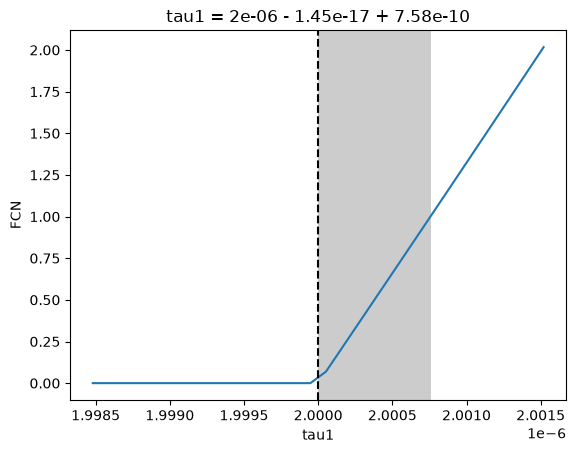

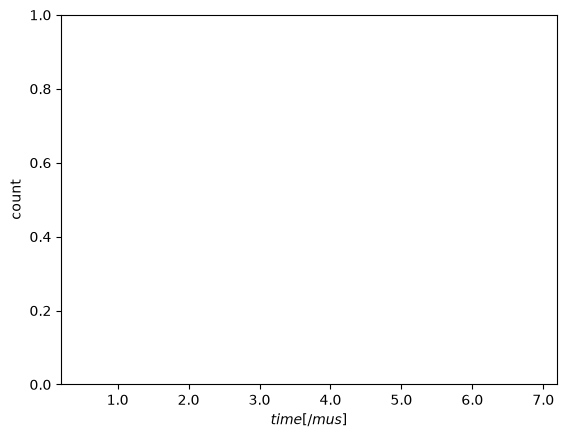

In [66]:
n_bins = 67

# cut dataset using data retrived in the "cuts" section
data_refact:np.ndarray = data[(data > 0.2e-6)&(data < 7.2e-6)]


# n = dataset_analysis( data_refact , exp , bins = n_bins , args= {"a": 1, "A": 0, "tau": TAU_MU})
# end(n)


# interpolation (the output is a Minuit object)
full_analysis = dataset_analysis( data_refact , exp_unif , bins = n_bins_void , args={"freq_exp1": 1-noiseFrequency,"tau1": TAU_MU , "A":0})
full_analysis.limits["freq_exp1"] = (0,1)
full_analysis.fixed["freq_exp1"] = True
full_analysis.limits["tau1"] = (2e-6,3e-6)

# calls Migrad, hesse and asymmetric errors, if the latter is not wanted add False keyword
end(full_analysis , True)


# plots the likelyhood profile so that you can graphically see how far we are from the true value
full_analysis.draw_mnprofile("tau1");

print(full_analysis.values)

# define tau_hat as our system estimate of the value
tau_hat = full_analysis.values["tau1"]

print(len(full_analysis.values))

void = plots(data_refact , full_analysis , r"$ time [ /mu s ] $" , "count")
a = 0


print(to_typst_table(full_analysis))

### Least Squares


try of an interpolation using Least Squares, it works the same as the others

In [67]:
data_refact:np.ndarray = data[(data > 0.4e-6)&(data < 7.3e-6)]

count_LS , edges_LS = np.histogram( data_refact , bins=n_bins_void , density=True)

edges_LS = [ (edges_LS[i+1] + edges_LS[i])/2 for i in range(len(count_LS))]

# fig = go.Figure()
# fig.add_trace( go.Scatter( x = edges_LS , y = count_LS, mode="lines" , name="p_value"))
# fig.show()


ls = LeastSquares( edges_LS , count_LS , np.sqrt(count_LS) , exp_unif_pdf) #type:ignore
exp_unif_args = {"a": 0.9, "N": len(data_refact),"b": 0, "tau": TAU_MU , "A":0 , "e": max(data_refact)}
minuit = Minuit( ls , min(data_refact) , max(data_refact), 0.9 , TAU_MU , 0)
minuit.limits["tau"] = (1e-6 , 3e-6)
minuit.limits["freq"] = (0,1)
minuit.fixed["A" , "min", "max"] = True # type: ignore
end(minuit, False)



┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.113e+05 (χ²/ndof = 662.6)│              Nfcn = 83               │
│ EDM = 1.7e-07 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ min  │  404e-9   │   4e-9    │            │            │         │         │  yes  │
│ 1 │ max  │  7.30e-6  │  0.07e-6  │            │            │         │         │  yes  │
│ 2 │ freq │ 986.3e-3  │  0.5e-3   │            │            │    0    │    1    │       │
│ 3 │ tau  │ 2.2536e-6 │ 0.0016e-6 │            │            │  1e-06  │  3e-06  │       │
│ 4 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────┬──────────────────────────────────────────────────────────────────┐
│      │          min          max         freq          tau            A │
├──────┼──────────────────────────────────────────────────────────────────┤
│  min │            0            0            0            0            0 │
│  max │            0            0            0            0            0 │
│ freq │            0            0     2.56e-07 731.6134e-15            0 │
│  tau │            0            0 731.6134e-15     2.51e-18            0 │
│    A │            0            0            0            0            0 │
└──────┴──────────────────────────────────────────────────────────────────┘

### Double Exponential


try to capture the muon decay in carbon but we don't have enough data to measure the small difference between it and the void tau

In [68]:
data_refact:np.ndarray = data[(data > 0.4e-6)&(data < 7.3e-6)]


double_exp_unif_args = {"freq_exp": 0.945, "relative_freq":0.1,  "tau1": tau_hat , "tau2":TAU_C, "A":0}
double_int = dataset_analysis( data_refact , double_exp_unif , bins = n_bins_void , args=double_exp_unif_args)
double_int.limits["freq_exp" , "relative_freq"] = (0.0 , 1.0)#type:ignore
double_int.fixed["tau1" , "freq_exp"] = True#type:ignore
double_int.limits["tau2"] = (1e-6 , 5e-6)
end(double_int, False)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 321.7 (χ²/ndof = 1.9)      │              Nfcn = 231              │
│ EDM = 1.29e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name          │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp      │   0.945   │   0.009   │            │            │    0    │    1    │  yes  │
│ 1 │ relative_freq │    1.0    │    0.8    │            │            │    0    │    1    │       │
│ 2 │ tau1          │  2.00e-6  │  0.02e-6  │            │            │         │         │  yes  │
│ 3 │ tau2          │ 2.157e-6  │ 0.012e-6  │            │            │  1e-06  │  5e-06  │       │
│ 4 │ A             │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────────────┬───────────────────────────────────────────────────────────────────────┐
│               │      freq_exp relative_freq          tau1          tau2             A │
├───────────────┼───────────────────────────────────────────────────────────────────────┤
│      freq_exp │             0             0             0             0             0 │
│ relative_freq │             0      4.37e-05             0  -8.73931e-12             0 │
│          tau1 │             0             0             0             0             0 │
│          tau2 │             0  -8.73931e-12             0       1.4e-16             0 │
│             A │             0             0             0             0             0 │
└───────────────┴───────────────────────────────────────────────────────────────────────┘

## Plot result + Discrepancy analysis


In [69]:
count,edges = np.histogram(data_refact , n_bins_void)


fig = go.Figure()
fig.add_trace(go.Bar(x=edges[:-1], y=count/len(data_refact), name='total', width=np.diff(edges)))

x_fit = np.linspace(min(data_refact) , max(data_refact) , n_bins_void)
y_fit = exp_unif_pdf( x_fit , min(data_refact) , max(data_refact), *full_analysis.values)*np.diff( edges )[0]
y_ideal_fit = exp_unif_pdf(x_fit , min(data_refact) , max(data_refact), full_analysis.values["freq_exp1"], TAU_MU , 0)*np.diff(edges)[0]
fig.add_trace(go.Scatter(x=x_fit, y=y_fit, mode='lines', name='fit', line=dict(shape='linear')))
fig.add_trace(go.Scatter(x=x_fit, y=y_ideal_fit, mode='lines', name='ideal fit', line=dict(shape='linear')))


In [70]:
# ho provato a vedere come fossero gli errori poissoniani usando i risultati dell'interpolazione come base

res = (count/len(data_refact)) - y_fit
res_ideal = count/len(data_refact) - y_ideal_fit

fig = go.Figure()
fig.add_trace(go.Scatter(x=x_fit, y=res, mode='markers',  name='residuals'))
fig.add_trace(go.Scatter(x=x_fit, y=res_ideal, mode='markers',  name='ideal residuals'))
fig.add_trace(go.Scatter(x=x_fit, y=res/count * len(data_refact), mode='markers',  name='relative residuals'))
fig.add_trace(go.Scatter(x=x_fit, y=res_ideal/count * len(data_refact), mode='markers',  name='relative ideal residuals'))

fig.show()


## Analysis multichannel dataset


In [71]:
data_g_refact = data_g[data_g>5e-7]
data_p_refact = data_p[data_p>5e-7]


print(len(data_g) , len(data_p))
exp_unif_args = {"freq_exp1": 0.9,  "tau1": TAU_MU , "A":0}
g = dataset_analysis( data_g_refact , exp_unif , bins = n_bins_void , args=exp_unif_args)
g.limits["freq_exp1"] = (0,1) #type:ignore
# g.fixed["e"] = True
end(g)

p = dataset_analysis( data_p_refact , exp_unif , bins = n_bins_void , args=exp_unif_args)
p.limits["freq_exp1"] = (0,1) #type:ignore
# p.fixed["e"] = True
end(p)




complete_void = np.append( data_g , data_p)
complete_void_refact = complete_void[complete_void>5e-7]


comp = dataset_analysis( complete_void_refact , exp_unif , bins = n_bins_void , args=exp_unif_args)
comp.limits["freq_exp1"] = (0,1) #type:ignore
# comp.fixed["e"] = True
end(comp)


14563 16272


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 180.6 (χ²/ndof = 1.1)      │              Nfcn = 110              │
│ EDM = 4.88e-09 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name      │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp1 │   0.908   │   0.027   │   -0.026   │   0.028    │    0    │    1    │       │
│ 1 │ tau1      │  2.23e-6  │  0.09e-6  │  -0.08e-6  │  0.09e-6   │         │         │       │
│ 2 │ A         │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┐
│          │       freq_exp1       │         tau1          │
├──────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.026   │   0.028   │ -0.08e-6  │  0.09e-6  │
│  Valid   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┘
┌───────────┬─────────────────────────────────────┐
│           │   freq_exp1        tau1           A │
├───────────┼─────────────────────────────────────┤
│ freq_exp1 │    0.000733 2.122473e-9           0 │
│      tau1 │ 2.122473e-9    7.44e-15       0e-15 │
│         A │           0       0e-15           0 │
└───────────┴─────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 176.4 (χ²/ndof = 1.1)      │              Nfcn = 119              │
│ EDM = 9.98e-07 (Goal: 0.0002)    │            time = 0.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name      │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp1 │   0.955   │   0.021   │   -0.020   │   0.021    │    0    │    1    │       │
│ 1 │ tau1      │  2.18e-6  │  0.06e-6  │  -0.06e-6  │  0.06e-6   │         │         │       │
│ 2 │ A         │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┐
│          │       freq_exp1       │         tau1          │
├──────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.020   │   0.021   │ -0.06e-6  │  0.06e-6  │
│  Valid   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┘
┌───────────┬─────────────────────────────────────┐
│           │   freq_exp1        tau1           A │
├───────────┼─────────────────────────────────────┤
│ freq_exp1 │    0.000423 1.174923e-9           0 │
│      tau1 │ 1.174923e-9    3.99e-15       0e-15 │
│         A │           0       0e-15           0 │
└───────────┴─────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 202.8 (χ²/ndof = 1.2)      │              Nfcn = 111              │
│ EDM = 1.64e-08 (Goal: 0.0002)    │            time = 0.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name      │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp1 │   0.937   │   0.016   │   -0.016   │   0.017    │    0    │    1    │       │
│ 1 │ tau1      │  2.20e-6  │  0.05e-6  │  -0.05e-6  │  0.05e-6   │         │         │       │
│ 2 │ A         │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┐
│          │       freq_exp1       │         tau1          │
├──────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.016   │   0.017   │ -0.05e-6  │  0.05e-6  │
│  Valid   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┘
┌───────────┬────────────────────────────────────────┐
│           │    freq_exp1         tau1            A │
├───────────┼────────────────────────────────────────┤
│ freq_exp1 │     0.000271 764.6090e-12            0 │
│      tau1 │ 764.6090e-12     2.63e-15            0 │
│         A │            0            0            0 │
└───────────┴────────────────────────────────────────┘

0.4999991115648587 2.22697664519238e-06
0.49999913088268294 2.1785540407751282e-06


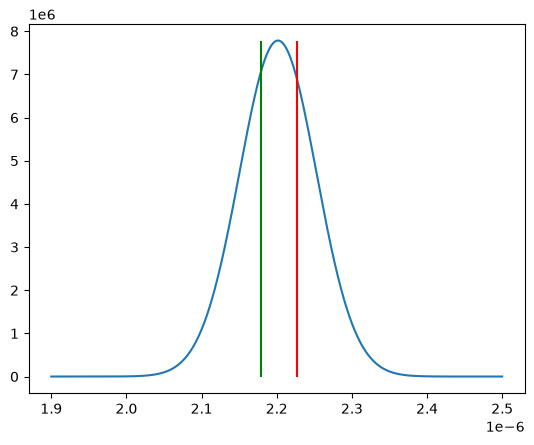

In [72]:
from scipy.stats import norm

hyp_test = norm( loc = comp.values["tau1"] , scale = comp.errors["tau1"])

x_plot = np.linspace( 1.9e-6 , 2.5e-6 , 1000)
y_plot = hyp_test.pdf( x_plot) # type: ignore

plt.plot( x_plot , y_plot)
plt.vlines( g.values["tau1"], 0 , max(y_plot) , color = "red")
plt.vlines( p.values["tau1"], 0 , max(y_plot), color = "green")

g_value = norm.sf( g.values["tau1"])
p_value = norm.sf( p.values["tau1"])

z_score_g = norm.ppf(1 - g_value)
z_score_p = norm.ppf(1 - p_value)


print( g_value , z_score_g)
print( p_value , z_score_p)


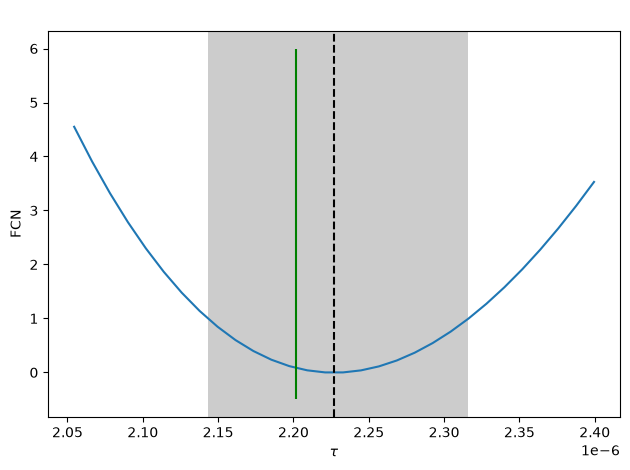

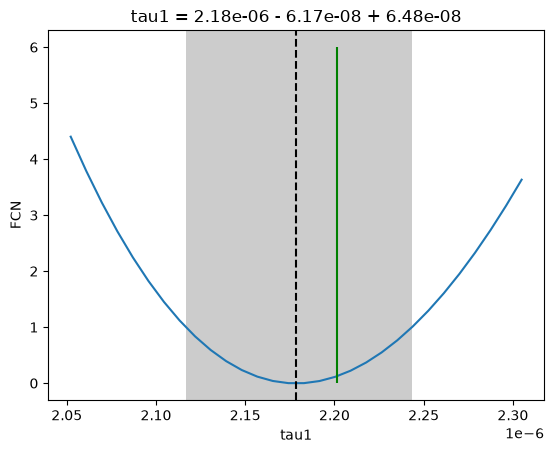

In [73]:
g.draw_mnprofile("tau1")
# p.draw_mnprofile("tau")
plt.title(" ")
plt.xlabel(r"$ \tau $")
plt.vlines(comp.values["tau1"] , -0.5  ,6 , colors="green")
plt.tight_layout()
plt.show()

p.draw_mnprofile("tau1")

plt.vlines(comp.values["tau1"] , 0  ,6 , colors="green")
plt.show()


## Pics


In [74]:
fig_1 = void.colour_plot(n_bins_void , False , ["Dataset" , r"$ exp \tau = (2.21 \pm 0,02) \mu s $" , r"$ uniform \nu = (3 \pm 1)\% $"])
 
fig_1.savefig("Photo/interpolation/void_components.pdf" , format="pdf")


170 170 170


<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_38692/3409764266.py:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel("time [$ \mu s $]")


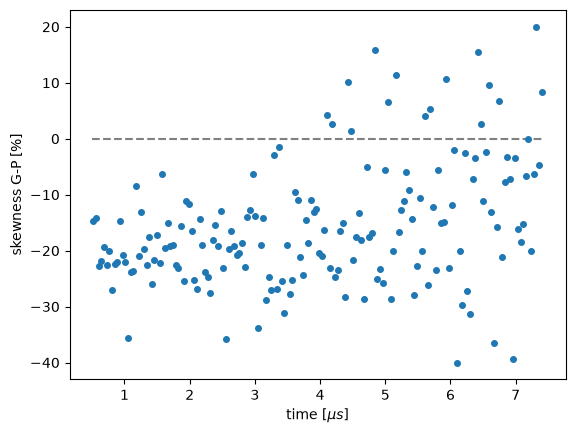

In [75]:
up = data_g_refact * 1e6
down = data_p_refact * 1e6


asym_void_range = (np.min(np.concatenate([up, down])), np.max(np.concatenate([up , down])))

count_u,edges = np.histogram( up , bins = n_bins_void , range = asym_void_range)
count_d,edges = np.histogram( down , bins = n_bins_void , range = asym_void_range)

bin_center = (edges[:-1] + edges[1:])/2


plt.errorbar( bin_center , (count_u - count_d)/(count_u + count_d)*100 , yerr = np.sqrt(count_u + count_d)/(len(up)+ len(down))*100 , xerr = 0.012e-6 , fmt="o" , markersize=4)
plt.hlines( 0 , xmin=asym_void_range[0] , xmax= asym_void_range[1] , linestyle="--" , color="grey")
plt.ylabel("skewness G-P [%]")
plt.xlabel("time [$ \mu s $]")

plt.savefig("Photo/interpolation/void_skewness.pdf" , format="pdf")


<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_38692/3773071591.py:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axes[1].set_xlabel('Time $ [ \mu s] $')


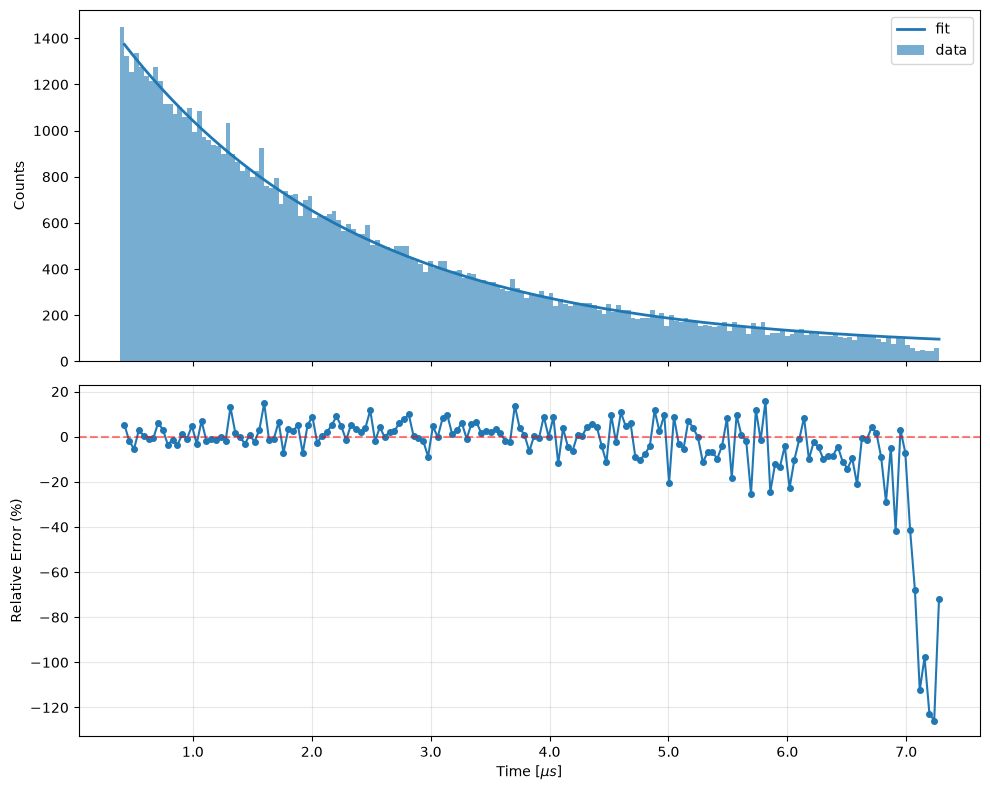

In [76]:
pic_data = data[(data > 0.4e-6)&(data < 7.3e-6)]
m = full_analysis

count, edges = np.histogram(pic_data, n_bins_void)
bin_centers = (edges[:-1] + edges[1:]) / 2
bin_widths = np.diff(edges)

# scale pdf to raw counts per bin
y_fit_counts = exp_unif_pdf(bin_centers, min(pic_data), max(pic_data), *m.values) * len(pic_data) * bin_widths

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# Top: histogram (raw counts) + fit (counts)
axes[0].bar(edges[:-1], count, width=bin_widths, alpha=0.6, label='data')
axes[0].plot(bin_centers, y_fit_counts, label='fit', linewidth=2)
axes[0].set_ylabel('Counts')
axes[0].legend()

# Bottom: relative errors (percent)
relative_errors = np.where(count > 0, (count - y_fit_counts) / count * 100, 0.0)
axes[1].plot(bin_centers, relative_errors, 'o-', markersize=4)
axes[1].axhline(0, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Time $ [ \mu s] $')
axes[1].set_ylabel('Relative Error (%)')
axes[1].grid(True, alpha=0.3)

axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x*1e6:.1f}'))

plt.tight_layout()
plt.savefig("Photo/interpolation/void_interp.pdf" , format = "pdf")



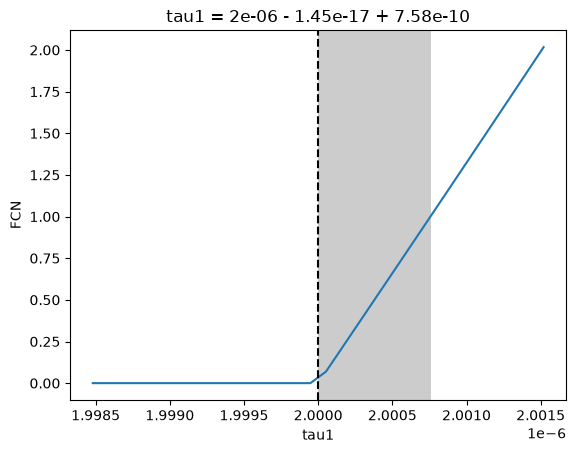

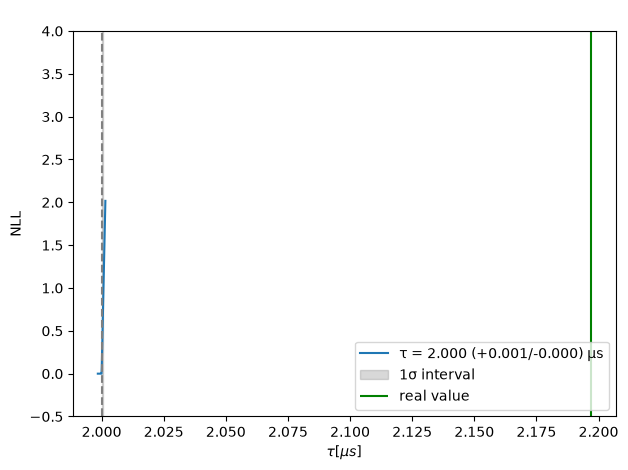

In [77]:
full_analysis.draw_mnprofile("tau1")



# 2. Get the current active axes
ax = plt.gca()

# 3. Grab the elements (iminuit usually draws the line first, then the fill)
# We filter for lines and collections
lines = ax.get_lines()

x = lines[0].get_xdata()
y = lines[0].get_ydata()

fig.clf()


fig, ax = plt.subplots(1, 1)

tau = full_analysis.values["tau1"]
err_low = -full_analysis.merrors["tau1"].lower
err_high = full_analysis.merrors["tau1"].upper
label = f"τ = {tau*1e6:.3f} (+{err_high*1e6:.3f}/-{err_low*1e6:.3f}) μs"
ax.plot(x, y, label=label)

left = full_analysis.values["tau1"] + full_analysis.merrors["tau1"].lower
right = full_analysis.values["tau1"] + full_analysis.merrors["tau1"].upper

ax.axvspan(left, right, color="gray", alpha=0.3, label="1σ interval")

ax.vlines(TAU_MU, -0.5, 6, colors="green", label="real value")
ax.vlines(full_analysis.values["tau1"], -0.5, 6, colors="grey", linestyles="--")

ax.set_ylim(-0.5, 4)

plt.title(" ")
plt.xlabel(r"$ \tau [ \mu s]$")
plt.ylabel("NLL")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x*1e6:.3f}'))
plt.tight_layout()
ax.legend(loc="lower right")
plt.savefig("Photo/interpolation/void_tau.pdf", format="pdf")


# NaCl Analysis


## interpolations


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 246.2 (χ²/ndof = 1.1)      │              Nfcn = 60               │
│ EDM = 3.99e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name          │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp      │   0.869   │   0.009   │            │            │    0    │    1    │  yes  │
│ 1 │ relative_freq │   0.119   │   0.035   │            │            │    0    │    1    │       │
│ 2 │ tau1          │  2.00e-6  │  0.02e-6  │            │            │         │         │  yes  │
│ 3 │ tau2          │  0.86e-6  │  0.19e-6  │            │            │         │         │       │
│ 4 │ A             │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────────────┬───────────────────────────────────────────────────────────────────────┐
│               │      freq_exp relative_freq          tau1          tau2             A │
├───────────────┼───────────────────────────────────────────────────────────────────────┤
│      freq_exp │             0        0.0000             0             0             0 │
│ relative_freq │        0.0000       0.00123        0.0000    6.40616e-9        0.0000 │
│          tau1 │             0        0.0000             0             0             0 │
│          tau2 │             0    6.40616e-9             0      3.78e-14             0 │
│             A │             0        0.0000             0             0             0 │
└───────────────┴───────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 260.9 (χ²/ndof = 1.2)      │              Nfcn = 322              │
│ EDM = 1.92e-05 (Goal: 0.0002)    │            time = 0.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name          │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp      │   0.869   │   0.009   │            │            │    0    │    1    │  yes  │
│ 1 │ relative_freq │999.994e-3 │656.233e-3 │-237.603e-3 │  0.006e-3  │    0    │    1    │       │
│ 2 │ tau1          │  2.00e-6  │  0.02e-6  │            │            │         │         │  yes  │
│ 3 │ tau2          │ 1.710e-6  │ 0.015e-6  │ -0.080e-6  │  0.015e-6  │         │         │       │
│ 4 │ A             │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┐
│          │     relative_freq     │         tau2          │
├──────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │-237603e-6 │   6e-6    │ -0.080e-6 │ 0.015e-6  │
│  Valid   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   True    │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┘
┌───────────────┬───────────────────────────────────────────────────────────────────────┐
│               │      freq_exp relative_freq          tau1          tau2             A │
├───────────────┼───────────────────────────────────────────────────────────────────────┤
│      freq_exp │             0          0e-6             0             0             0 │
│ relative_freq │          0e-6      8.58e-06          0e-6   1.86765e-12          0e-6 │
│          tau1 │             0          0e-6             0             0             0 │
│          tau2 │             0   1.86765e-12             0      2.29e-16             0 │
│             A │             0          0e-6             0             0             0 │
└───────────────┴───────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 331.3 (χ²/ndof = 1.5)      │              Nfcn = 344              │
│ EDM = 2.21e-06 (Goal: 0.0002)    │            time = 1.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name          │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp      │   0.869   │   0.009   │            │            │    0    │    1    │  yes  │
│ 1 │ relative_freq │   0.54    │   0.29    │   -0.20    │    0.46    │    0    │    1    │       │
│ 2 │ tau1          │  2.00e-6  │  0.02e-6  │            │            │         │         │  yes  │
│ 3 │ tau2          │  1.56e-6  │  0.21e-6  │  -0.20e-6  │  0.19e-6   │         │         │       │
│ 4 │ A             │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┐
│          │     relative_freq     │         tau2          │
├──────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.20   │   0.46    │ -0.20e-6  │  0.19e-6  │
│  Valid   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   True    │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┘
┌───────────────┬───────────────────────────────────────────────────────────────────────┐
│               │      freq_exp relative_freq          tau1          tau2             A │
├───────────────┼───────────────────────────────────────────────────────────────────────┤
│      freq_exp │             0          0.00             0             0             0 │
│ relative_freq │          0.00        0.0936          0.00   65.31419e-9          0.00 │
│          tau1 │             0          0.00             0             0             0 │
│          tau2 │             0   65.31419e-9             0      4.59e-14             0 │
│             A │             0          0.00             0             0             0 │
└───────────────┴───────────────────────────────────────────────────────────────────────┘

[<matplotlib.patches.Rectangle object at 0x7f4ffc40b4d0>, <Axes: >]
#figure(
  #table(
  columns: (1fr, 1fr, 1fr),
  align: (left, right, right),
  stroke: 0.5pt + luma(120),
  fill: (x, y) => if y == 0 { luma(240) } else { none },
  [*Parameter*], [*Value*], [*Uncertainty*],
  [freq_exp], [0.8692], [0.0087],
  [relative_freq], [0.5373], [0.2871],
  [tau1], [2.0000e-06], [2.0000e-08],
  [tau2], [1.5638e-06], [2.1433e-07],
  [A], [0.0000e+00], [1.0000e-01],
),
  caption: [Fit Parameters],
)


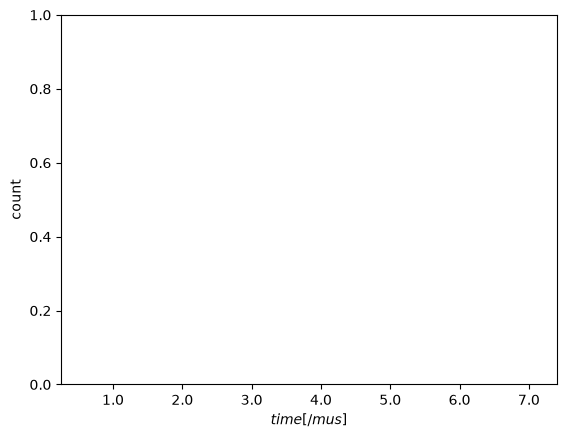

In [78]:

# cuts retrived from the "cuts" section
salt_g_refact = salt_g[salt_g>2.5e-7]
salt_p_refact = salt_p[salt_p>2.5e-7]




# initial parameters for the interpolation
double_exp_unif_args = {"freq_exp": 1 - noiseFrequency, "relative_freq":0.2,  "tau1": tau_hat , "tau2":TAU_NaCl, "A":0}


# interpolation (the output is a Minuit object)
na_g = dataset_analysis( salt_g_refact , double_exp_unif , bins = n_bins_na , args=double_exp_unif_args)
na_g.limits["freq_exp" , "relative_freq"] = (0,1) #type:ignore
na_g.fixed["freq_exp"] = True
na_g.fixed["tau1"] = True#type:ignore

# calls Migrad, hesse and asymmetric errors, if the latter is not wanted add False keyword
end(na_g , False)



# interpolation (the output is a Minuit object)
na_p = dataset_analysis( salt_p_refact , double_exp_unif , bins = n_bins_na , args=double_exp_unif_args)
na_p.limits["freq_exp" , "relative_freq"] = (0,1) #type:ignore
na_p.fixed["freq_exp"] = True
na_p.fixed["tau1"] = True#type:ignore
# p.fixed["e"] = True

# calls Migrad, hesse and asymmetric errors, if the latter is not wanted add False keyword
end(na_p)



# interpolation (the output is a Minuit object)
complete_salt = np.append( salt_g , salt_p)
complete_salt_refact = complete_salt[complete_salt>2.5e-7]

na_comp = dataset_analysis( complete_salt_refact , double_exp_unif , bins = n_bins_na , args=double_exp_unif_args)
na_comp.limits["freq_exp" , "relative_freq"] = (0,1) #type:ignore
na_comp.fixed["freq_exp"] = True
na_comp.fixed["tau1"] = True#type:ignore


# calls Migrad, hesse and asymmetric errors, if the latter is not wanted add False keyword
end(na_comp , True)


na = plots( complete_salt_refact, na_comp , r"$ time [ /mu s ] $" , "count")
a = 0

print(to_typst_table(na_comp))

## Plot result + Discrepancy analysis


In [79]:
count,edges = np.histogram(data_refact , n_bins_na)


fig = go.Figure()
fig.add_trace(go.Bar(x=edges[:-1], y=count/len(data_refact), name='total', width=np.diff(edges)))

x_fit = np.linspace(min(data_refact) , max(data_refact) , n_bins_na)
y_fit = exp_unif_pdf( x_fit , min(data_refact) , max(data_refact), *full_analysis.values)*np.diff( edges )[0]
y_ideal_fit = exp_unif_pdf(x_fit , min(data_refact) , max(data_refact), full_analysis.values["freq_exp1"], TAU_MU , 0)*np.diff(edges)[0]
fig.add_trace(go.Scatter(x=x_fit, y=y_fit, mode='lines', name='fit', line=dict(shape='linear')))
fig.add_trace(go.Scatter(x=x_fit, y=y_ideal_fit, mode='lines', name='ideal fit', line=dict(shape='linear')))


In [80]:
# ho provato a vedere come fossero gli errori poissoniani usando i risultati dell'interpolazione come base

res = (count/len(data_refact)) - y_fit
res_ideal = count/len(data_refact) - y_ideal_fit

fig = go.Figure()
fig.add_trace(go.Scatter(x=x_fit, y=res, mode='markers',  name='residuals'))
fig.add_trace(go.Scatter(x=x_fit, y=res_ideal, mode='markers',  name='ideal residuals'))
fig.add_trace(go.Scatter(x=x_fit, y=res/count * len(data_refact), mode='markers',  name='relative residuals'))
fig.add_trace(go.Scatter(x=x_fit, y=res_ideal/count * len(data_refact), mode='markers',  name='relative ideal residuals'))

fig.show()


## analysis gap
3 images stand for 3 different algorithm used in the parser:
- diff double *ending* point from the triple 
- using the trigger as starting point
- cutting off the double and using the initial triple point


7.6e-08


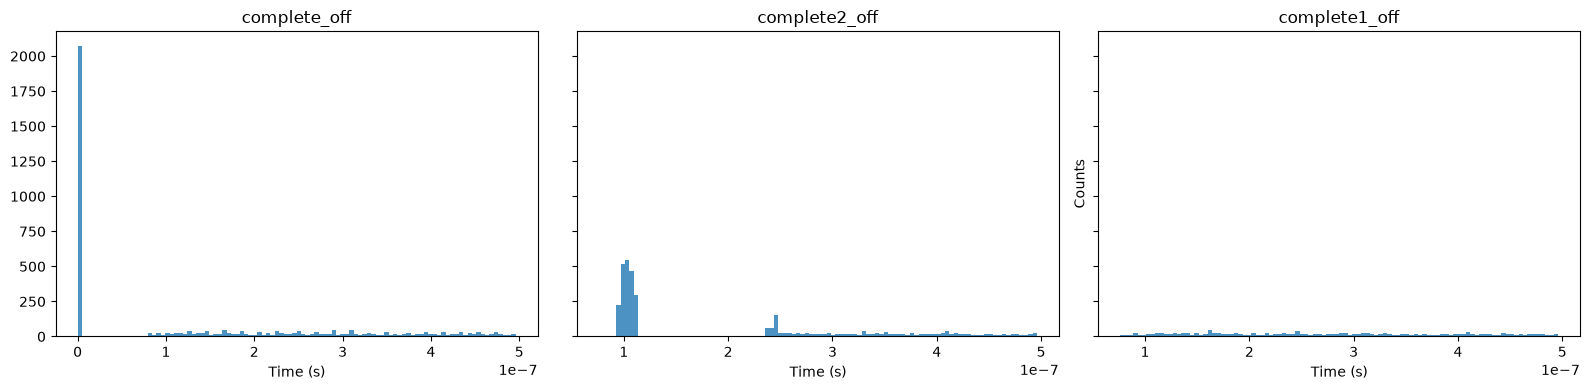

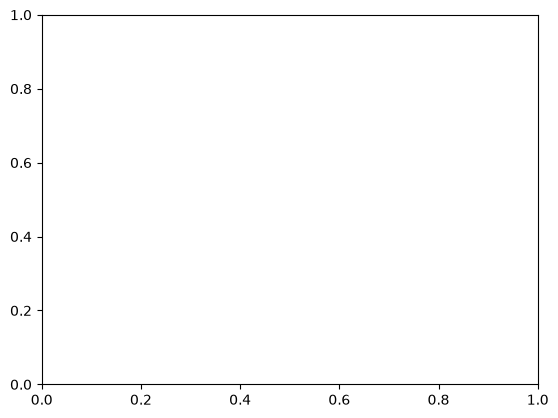

In [81]:
try_data = np.genfromtxt("Data/timestamp/try.csv", delimiter=",")
try1_data = np.genfromtxt("Data/timestamp/try1.csv", delimiter=",")
try2_data = np.genfromtxt("Data/timestamp/try2.csv", delimiter=",")

try_g, try_p = dataset_splitter(try_data)
try1_g, try1_p = dataset_splitter(try1_data)
try2_g, try2_p = dataset_splitter(try2_data)

complete_try = np.concatenate((try_g, try_p))
complete1_try = np.concatenate((try1_g, try1_p))
complete2_try = np.concatenate((try2_g, try2_p))



complete_off = complete_try[complete_try < 5e-7]
complete1_off = complete1_try[complete1_try < 5e-7]
complete2_off = complete2_try[complete2_try < 5e-7]

c = np.where( complete_off >5e-9, complete_off , np.inf)
print(min(c))

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

axes[2].hist(complete1_off, bins=100, alpha=0.8)
axes[2].set_title("complete1_off")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Counts")

axes[0].hist(complete_off, bins=100, alpha=0.8)
axes[0].set_title("complete_off")
axes[0].set_xlabel("Time (s)")

axes[1].hist(complete2_off, bins=100, alpha=0.8)
axes[1].set_title("complete2_off")
axes[1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

fig,ax = plt.subplots( 1,1)


## Pics


In [82]:
fig_2 = na.colour_plot(n_bins_na , False , ["Dataset" , r"$\tau = (2.21 \pm 0.02) \mu s$" , r"$ \tau = (0.68 \pm 0.08) \mu s$" , r"$ \nu = (0.05 \pm 0.02)\%$"])
fig_2.savefig("Photo/interpolation/na_components.pdf" , format="pdf")


<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_38692/2052717326.py:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel("time [$ \mu s $]")


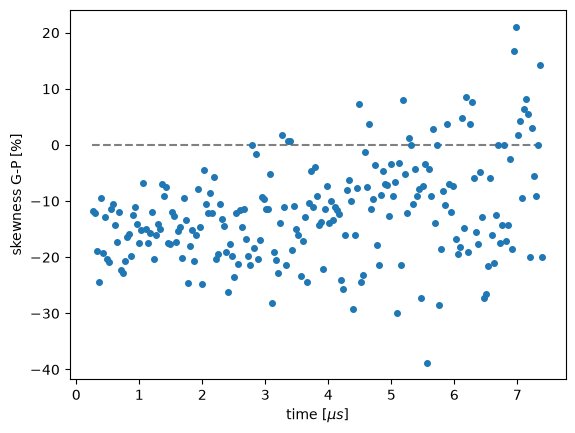

In [83]:
up = salt_g_refact * 1e6
down = salt_p_refact * 1e6


asym_void_range = (np.min(np.concatenate([up, down])), np.max(np.concatenate([up , down])))

count_u,edges = np.histogram( up , bins = n_bins_na , range = asym_void_range)
count_d,edges = np.histogram( down , bins = n_bins_na , range = asym_void_range)

bin_center = (edges[:-1] + edges[1:])/2


plt.errorbar( bin_center , (count_u - count_d)/(count_u + count_d)*100 , yerr = np.sqrt(count_u + count_d)/(len(up)+ len(down))*100 , xerr = 0.012e-6 , fmt="o" , markersize=4)
plt.hlines( 0 , xmin=asym_void_range[0] , xmax= asym_void_range[1] , linestyle="--" , color="grey")
plt.ylabel("skewness G-P [%]")
plt.xlabel("time [$ \mu s $]")

plt.savefig("Photo/interpolation/salt_skewness.pdf" , format="pdf")


<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_38692/2732566776.py:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axes[1].set_xlabel('Time $ [ \mu s] $')


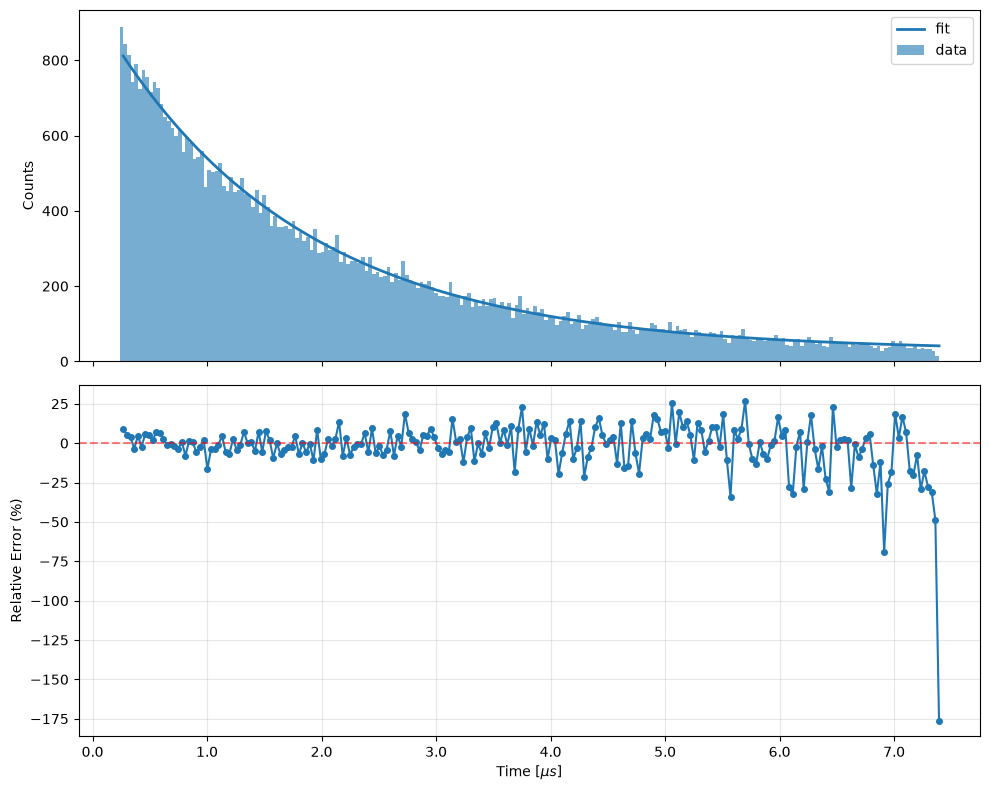

In [84]:
pic_data = complete_salt_refact
m = na_comp

count, edges = np.histogram(pic_data, n_bins_na)
bin_centers = (edges[:-1] + edges[1:]) / 2
bin_widths = np.diff(edges)

# scale pdf to raw counts per bin
y_fit_counts = double_exp_unif_pdf(bin_centers, min(pic_data), max(pic_data), *m.values) * len(pic_data) * bin_widths

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# Top: histogram (raw counts) + fit (counts)
axes[0].bar(edges[:-1], count, width=bin_widths, alpha=0.6, label='data')
axes[0].plot(bin_centers, y_fit_counts, label='fit', linewidth=2)
axes[0].set_ylabel('Counts')
axes[0].legend()

# Bottom: relative errors (percent)
relative_errors = np.where(count > 0, (count - y_fit_counts) / count * 100, 0.0)
axes[1].plot(bin_centers, relative_errors, 'o-', markersize=4)
axes[1].axhline(0, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Time $ [ \mu s] $')
axes[1].set_ylabel('Relative Error (%)')
axes[1].grid(True, alpha=0.3)

axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x,p: f'{x*1e6:.1f}'))

plt.tight_layout()
plt.savefig("Photo/interpolation/salt_interp.pdf" , format = "pdf")


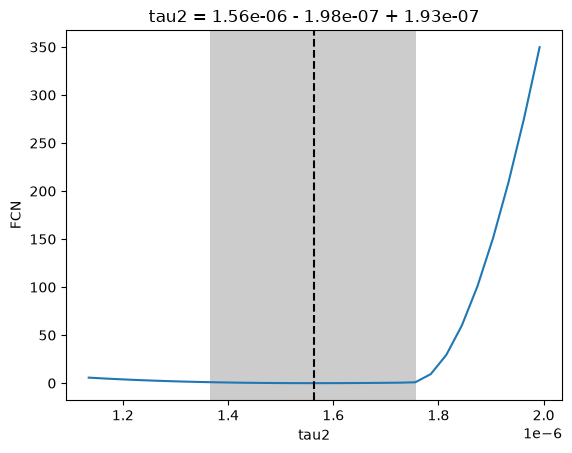

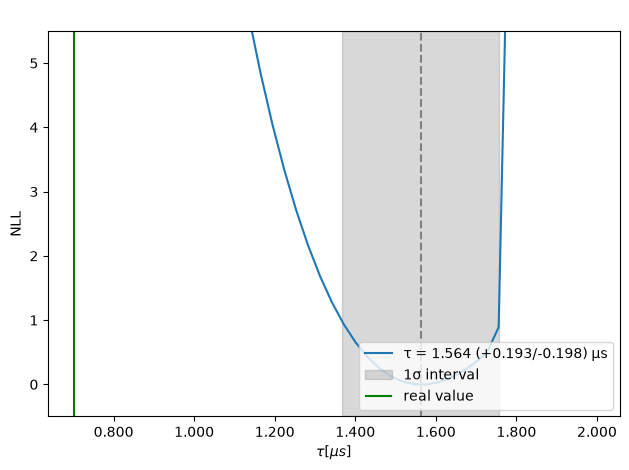

In [85]:
na_comp.draw_mnprofile("tau2")



# 2. Get the current active axes
ax = plt.gca()

# 3. Grab the elements (iminuit usually draws the line first, then the fill)
# We filter for lines and collections
lines = ax.get_lines()

x = lines[0].get_xdata()
y = lines[0].get_ydata()

fig.clf()


fig, ax = plt.subplots(1, 1)

tau = na_comp.values["tau2"]
err_low = -na_comp.merrors["tau2"].lower
err_high = na_comp.merrors["tau2"].upper
label = f"τ = {tau*1e6:.3f} (+{err_high*1e6:.3f}/-{err_low*1e6:.3f}) μs"
ax.plot(x, y, label=label)

left = na_comp.values["tau2"] + na_comp.merrors["tau2"].lower
right = na_comp.values["tau2"] + na_comp.merrors["tau2"].upper

ax.axvspan(left, right, color="gray", alpha=0.3, label="1σ interval")

ax.vlines(TAU_NaCl, -0.5, 6, colors="green", label="real value")
ax.vlines(na_comp.values["tau2"], -0.5, 6, colors="grey", linestyles="--")

ax.set_ylim(-0.5, 5.5)

plt.title(" ")
plt.xlabel(r"$ \tau [ \mu s]$")
plt.ylabel("NLL")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x*1e6:.3f}'))
plt.tight_layout()
ax.legend(loc="lower right")
plt.savefig("Photo/interpolation/na_tau.pdf", format="pdf")

# Al analysis


## interpolations


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 230.4 (χ²/ndof = 1.4)      │              Nfcn = 141              │
│ EDM = 1.57e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name          │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp      │   0.869   │   0.009   │            │            │    0    │    1    │  yes  │
│ 1 │ relative_freq │    1.0    │    0.6    │            │            │    0    │    1    │       │
│ 2 │ tau1          │  2.00e-6  │  0.02e-6  │            │            │         │         │  yes  │
│ 3 │ tau2          │ 1.708e-6  │ 0.017e-6  │            │            │         │         │       │
│ 4 │ A             │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────────────┬───────────────────────────────────────────────────────────────────────┐
│               │      freq_exp relative_freq          tau1          tau2             A │
├───────────────┼───────────────────────────────────────────────────────────────────────┤
│      freq_exp │             0          0e-6             0             0             0 │
│ relative_freq │          0e-6      4.46e-06          0e-6    957.38e-15          0e-6 │
│          tau1 │             0          0e-6             0             0             0 │
│          tau2 │             0    957.38e-15             0      2.95e-16             0 │
│             A │             0          0e-6             0             0             0 │
└───────────────┴───────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 212.4 (χ²/ndof = 1.3)      │              Nfcn = 115              │
│ EDM = 2.34e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name          │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp      │   0.869   │   0.009   │            │            │    0    │    1    │  yes  │
│ 1 │ relative_freq │   1.00    │   0.04    │            │            │    0    │    1    │       │
│ 2 │ tau1          │  2.00e-6  │  0.02e-6  │            │            │         │         │  yes  │
│ 3 │ tau2          │ 1.559e-6  │ 0.015e-6  │            │            │         │         │       │
│ 4 │ A             │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────────────┬───────────────────────────────────────────────────────────────────────┐
│               │      freq_exp relative_freq          tau1          tau2             A │
├───────────────┼───────────────────────────────────────────────────────────────────────┤
│      freq_exp │             0             0             0             0             0 │
│ relative_freq │             0      1.36e-09             0     -0.23e-15             0 │
│          tau1 │             0             0             0             0             0 │
│          tau2 │             0     -0.23e-15             0      2.17e-16             0 │
│             A │             0             0             0             0             0 │
└───────────────┴───────────────────────────────────────────────────────────────────────┘

21779 22879


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 298.7 (χ²/ndof = 1.9)      │              Nfcn = 210              │
│ EDM = 1.23e-07 (Goal: 0.0002)    │            time = 0.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name          │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp      │   0.869   │   0.009   │            │            │    0    │    1    │  yes  │
│ 1 │ relative_freq │999.9999996e-3│40.0097213e-3│-38.6266258e-3│0.0000004e-3│    0    │    1    │       │
│ 2 │ tau1          │  2.00e-6  │  0.02e-6  │            │            │         │         │  yes  │
│ 3 │ tau2          │ 1.632e-6  │ 0.011e-6  │ -0.015e-6  │  0.011e-6  │         │         │       │
│ 4 │ A             │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┐
│          │     relative_freq     │         tau2          │
├──────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │-38626625.8e-9│  0.4e-9   │ -0.015e-6 │ 0.011e-6  │
│  Valid   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   True    │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┘
┌───────────────┬───────────────────────────────────────────────────────────────────────┐
│               │      freq_exp relative_freq          tau1          tau2             A │
├───────────────┼───────────────────────────────────────────────────────────────────────┤
│      freq_exp │             0             0             0             0             0 │
│ relative_freq │             0      6.02e-11             0     -0.15e-15             0 │
│          tau1 │             0             0             0             0             0 │
│          tau2 │             0     -0.15e-15             0      1.26e-16             0 │
│             A │             0             0             0             0             0 │
└───────────────┴───────────────────────────────────────────────────────────────────────┘

[<matplotlib.patches.Rectangle object at 0x7f4ffdcc96d0>, <Axes: >]
#figure(
  #table(
  columns: (1fr, 1fr, 1fr),
  align: (left, right, right),
  stroke: 0.5pt + luma(120),
  fill: (x, y) => if y == 0 { luma(240) } else { none },
  [*Parameter*], [*Value*], [*Uncertainty*],
  [freq_exp], [0.8692], [0.0087],
  [relative_freq], [1.0000], [0.0400],
  [tau1], [2.0000e-06], [2.0000e-08],
  [tau2], [1.6319e-06], [1.1233e-08],
  [A], [0.0000e+00], [1.0000e-01],
),
  caption: [Fit Parameters],
)


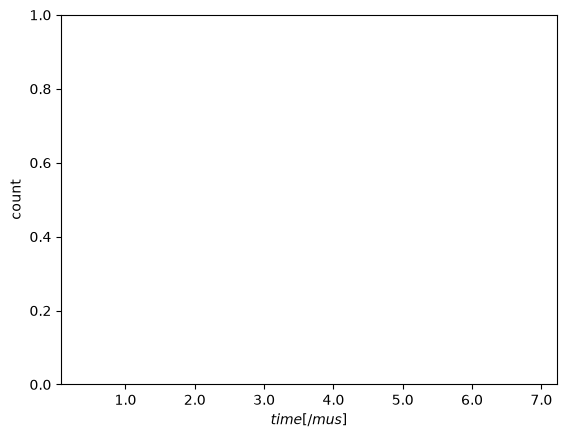

In [86]:
complete_al = np.append( al_g , al_p)

# no cuts in accordance to the latest section
al_g_refact = al_g
al_p_refact = al_p
complete_al_refact = complete_al

# al_g_refact = al_g
# al_p_refact = al_p
# complete_al_refact = complete_al




# initial coefficients for the interpolation 
double_exp_unif_args = {"freq_exp": 1-noiseFrequency, "relative_freq":0.1,  "tau1": tau_hat , "tau2":TAU_NaCl, "A":0}


# interpolation (the output is a Minuit object)
g = dataset_analysis( al_g_refact , double_exp_unif , bins = n_bins_al , args=double_exp_unif_args)
g.limits["freq_exp" , "relative_freq"] = (0.0 , 1.0)#type:ignore
g.fixed["freq_exp"] = True
g.fixed["tau1"] = True#type:ignore
# calls Migrad, hesse and asymmetric errors, if the latter is not wanted add False keyword
end(g , False)


# interpolation (the output is a Minuit object)
p = dataset_analysis( al_p_refact , double_exp_unif , bins = n_bins_al , args=double_exp_unif_args)
p.limits["freq_exp" , "relative_freq"] = (0.0 , 1.0)#type:ignore
p.fixed["freq_exp"] = True
p.fixed["tau1"] = True#type:ignore
# p.fixed["e"] = True
# calls Migrad, hesse and asymmetric errors, if the latter is not wanted add False keyword
end(p,False)




print(len(al_g) , len(al_p))

# interpolation (the output is a Minuit object)
al_comp = dataset_analysis( complete_al_refact , double_exp_unif , bins = n_bins_al , args=double_exp_unif_args)
al_comp.limits["freq_exp" , "relative_freq"] = (0.0 , 1.0)#type:ignore
al_comp.fixed["freq_exp"] = True
al_comp.fixed["tau1"] = True#type:ignore
# comp.fixed["e"] = True

# calls Migrad, hesse and asymmetric errors, if the latter is not wanted add False keyword
end(al_comp)

al = plots( complete_al_refact, al_comp , r"$ time [ /mu s ] $" , "count")
a = 0
print(to_typst_table(al_comp))

## Double Minerva


In [87]:
# ch1 = minerva
complete_dMal = np.append( dMal_g , dMal_m)



dMal_g_refact = dMal_g
dMal_m_refact = dMal_m[dMal_m > 2e-6]
complete_dMal_refact = complete_dMal

# dMal_g_refact = dMal_g
# dMal_m_refact = dMal_m
# complete_dMal_refact = complete_dMal



# coefficients for the inteprolation
double_exp_unif_args = {"freq_exp": 0.9, "relative_freq":0.1,  "tau1": tau_hat , "tau2":TAU_NaCl, "A":0}


# interpolation (the output is a Minuit object)
g = dataset_analysis( dMal_g_refact , double_exp_unif , bins = n_bins_al , args=double_exp_unif_args)
g.limits["freq_exp" , "relative_freq"] = (0.0 , 1.0)#type:ignore
g.fixed["tau1"] = True
end(g , False)

# interpolation (the output is a Minuit object)
m = dataset_analysis( dMal_m_refact , double_exp_unif , bins = n_bins_al , args=double_exp_unif_args)
m.limits["freq_exp" , "relative_freq"] = (0.0 , 1.0)#type:ignore
m.fixed["tau1"] = True
# p.fixed["e"] = True

# calls Migrad, hesse and asymmetric errors, if the latter is not wanted add False keyword
end(m , False)






# interpolation (the output is a Minuit object)
comp = dataset_analysis( complete_dMal_refact , double_exp_unif , bins = n_bins_al , args=double_exp_unif_args)
comp.limits["freq_exp" , "relative_freq"] = (0.0 , 1.0)#type:ignore
comp.fixed["tau1"] = True
# comp.fixed["e"] = True
end(comp , False)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 433.1 (χ²/ndof = 2.7)      │              Nfcn = 103              │
│ EDM = 5.73e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name          │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp      │   0.947   │   0.008   │            │            │    0    │    1    │       │
│ 1 │ relative_freq │   0.14    │   0.04    │            │            │    0    │    1    │       │
│ 2 │ tau1          │  2.00e-6  │  0.02e-6  │            │            │         │         │  yes  │
│ 3 │ tau2          │  0.98e-6  │  0.15e-6  │            │            │         │         │       │
│ 4 │ A             │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────────────┬───────────────────────────────────────────────────────────────────────┐
│               │      freq_exp relative_freq          tau1          tau2             A │
├───────────────┼───────────────────────────────────────────────────────────────────────┤
│      freq_exp │      6.52e-05      -0.27e-3             0  -842.373e-12             0 │
│ relative_freq │      -0.27e-3       0.00165        0.0000   5.685071e-9        0.0000 │
│          tau1 │             0        0.0000             0             0             0 │
│          tau2 │  -842.373e-12   5.685071e-9             0      2.22e-14             0 │
│             A │             0        0.0000             0             0             0 │
└───────────────┴───────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 528 (χ²/ndof = 3.3)        │              Nfcn = 281              │
│ EDM = nan (Goal: 0.0002)         │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name          │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp      │ 9.9985e-1 │    nan    │            │            │    0    │    1    │       │
│ 1 │ relative_freq │ 7.2464e-2 │    nan    │            │            │    0    │    1    │       │
│ 2 │ tau1          │  2.00e-6  │  0.02e-6  │            │            │         │         │  yes  │
│ 3 │ tau2          │ 1.7499e3  │    nan    │            │            │         │         │       │
│ 4 │ A             │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────────────┬───────────────────────────────────────────────────────────────────────┐
│               │      freq_exp relative_freq          tau1          tau2             A │
├───────────────┼───────────────────────────────────────────────────────────────────────┤
│      freq_exp │           nan           nan             0           nan             0 │
│ relative_freq │           nan           nan             0           nan             0 │
│          tau1 │             0             0             0             0             0 │
│          tau2 │           nan           nan             0           nan             0 │
│             A │             0             0             0             0             0 │
└───────────────┴───────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1348 (χ²/ndof = 8.5)       │              Nfcn = 118              │
│ EDM = 2.78e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name          │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp      │  0.9844   │  0.0034   │            │            │    0    │    1    │       │
│ 1 │ relative_freq │   0.102   │   0.005   │            │            │    0    │    1    │       │
│ 2 │ tau1          │  2.00e-6  │  0.02e-6  │            │            │         │         │  yes  │
│ 3 │ tau2          │ 0.295e-6  │ 0.015e-6  │            │            │         │         │       │
│ 4 │ A             │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────────────┬───────────────────────────────────────────────────────────────────────┐
│               │      freq_exp relative_freq          tau1          tau2             A │
├───────────────┼───────────────────────────────────────────────────────────────────────┤
│      freq_exp │      1.13e-05     -0.008e-3             0 -18.02366e-12             0 │
│ relative_freq │     -0.008e-3      2.17e-05             0  53.34030e-12             0 │
│          tau1 │             0             0             0             0             0 │
│          tau2 │ -18.02366e-12  53.34030e-12             0      2.38e-16             0 │
│             A │             0             0             0             0             0 │
└───────────────┴───────────────────────────────────────────────────────────────────────┘

## Pics


contributes pic

In [88]:

fig_3 = al.colour_plot(n_bins_al , False , ["Dataset" , r"$ \tau = (2.22 \pm 0.02) \mu s$" , r"$ \tau = (0.86 \pm 0.08) \mu s$" , r"$ \nu = (0.04 \pm 0.03)\%$ "])
fig_3.savefig("Photo/interpolation/al_components.pdf" , format="pdf")


asymmetry

<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_38692/1246521016.py:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel("time [$ \mu s $]")


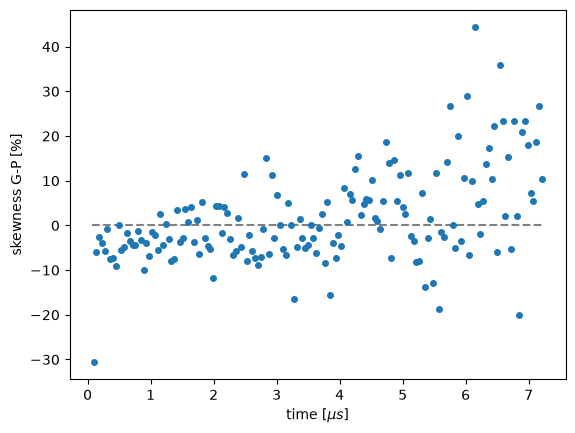

In [89]:
up = al_g * 1e6
down = al_p * 1e6


asym_void_range = (np.min(np.concatenate([up, down])), np.max(np.concatenate([up , down])))

count_u,edges = np.histogram( up , bins = n_bins_al , range = asym_void_range)
count_d,edges = np.histogram( down , bins = n_bins_al , range = asym_void_range)

bin_center = (edges[:-1] + edges[1:])/2


plt.errorbar( bin_center , (count_u - count_d)/(count_u + count_d)*100 , yerr = np.sqrt(count_u + count_d)/(len(up)+ len(down))*100 , xerr = 0.012e-6 , fmt="o" , markersize=4)
plt.hlines( 0 , xmin=asym_void_range[0] , xmax= asym_void_range[1] , linestyle="--" , color="grey")
plt.ylabel("skewness G-P [%]")
plt.xlabel("time [$ \mu s $]")

plt.savefig("Photo/interpolation/al_skewness.pdf" , format="pdf")


interpolation results + errors 

<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_38692/1859260411.py:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axes[1].set_xlabel('Time $ [ \mu s] $')


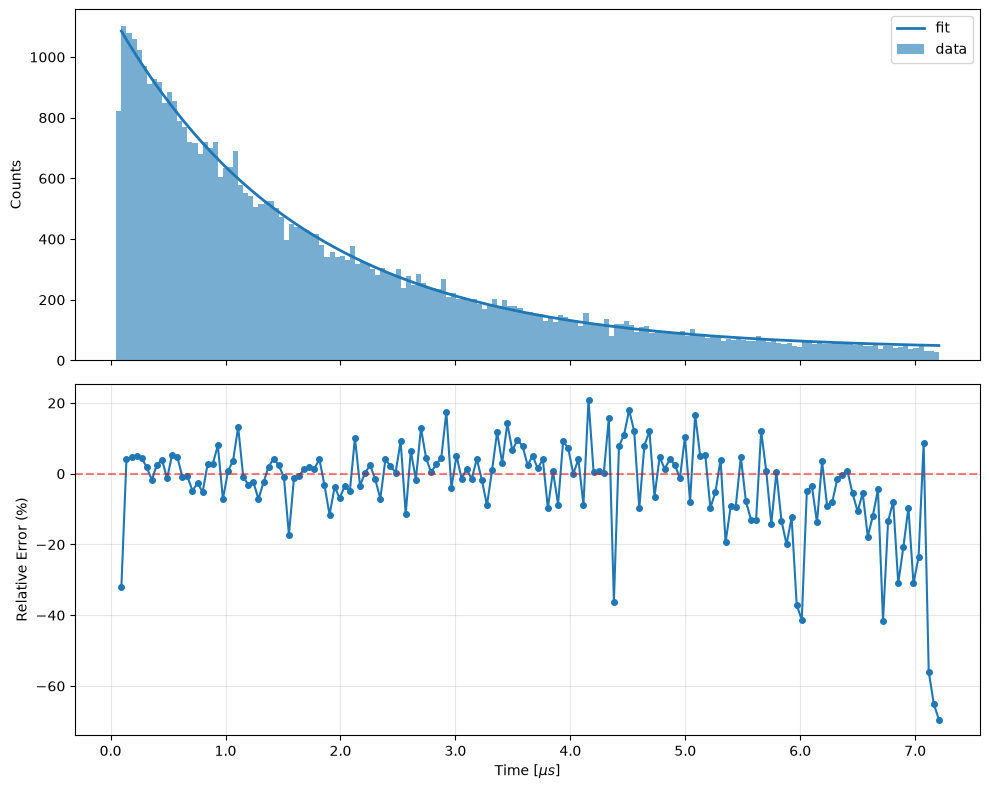

In [90]:
pic_data = complete_al_refact
m = al_comp

count, edges = np.histogram(pic_data, n_bins_al)
bin_centers = (edges[:-1] + edges[1:]) / 2
bin_widths = np.diff(edges)

# scale pdf to raw counts per bin
y_fit_counts = double_exp_unif_pdf(bin_centers, min(pic_data), max(pic_data), *m.values) * len(pic_data) * bin_widths

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# Top: histogram (raw counts) + fit (counts)
axes[0].bar(edges[:-1], count, width=bin_widths, alpha=0.6, label='data')
axes[0].plot(bin_centers, y_fit_counts, label='fit', linewidth=2)
axes[0].set_ylabel('Counts')
axes[0].legend()

# Bottom: relative errors (percent)
relative_errors = np.where(count > 0, (count - y_fit_counts) / count * 100, 0.0)
axes[1].plot(bin_centers, relative_errors, 'o-', markersize=4)
axes[1].axhline(0, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Time $ [ \mu s] $')
axes[1].set_ylabel('Relative Error (%)')
axes[1].grid(True, alpha=0.3)

axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x,p: f'{x*1e6:.1f}'))

plt.tight_layout()
plt.savefig("Photo/interpolation/al_interp.pdf" , format = "pdf")


pic that describes the goodness of the interpolation with respect to the expected value

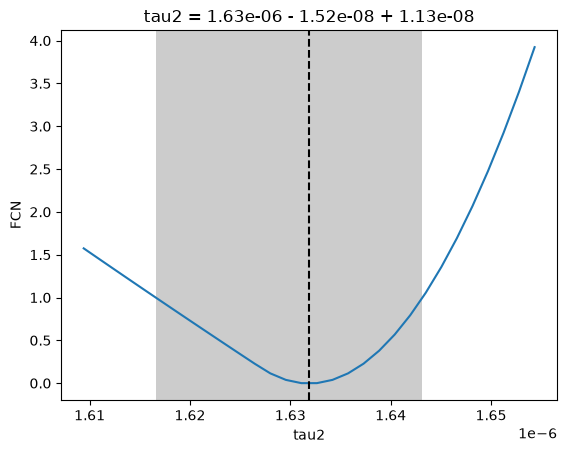

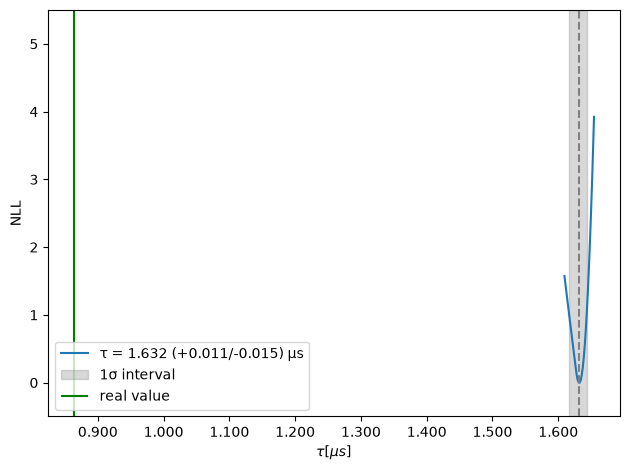

In [91]:
al_comp.draw_mnprofile("tau2")



# 2. Get the current active axes
ax = plt.gca()

# 3. Grab the elements (iminuit usually draws the line first, then the fill)
# We filter for lines and collections
lines = ax.get_lines()

x = lines[0].get_xdata()
y = lines[0].get_ydata()

fig.clf()


fig, ax = plt.subplots(1, 1)

tau = al_comp.values["tau2"]
err_low = -al_comp.merrors["tau2"].lower
err_high = al_comp.merrors["tau2"].upper
label = f"τ = {tau*1e6:.3f} (+{err_high*1e6:.3f}/-{err_low*1e6:.3f}) μs"
ax.plot(x, y, label=label)

left = al_comp.values["tau2"] + al_comp.merrors["tau2"].lower
right = al_comp.values["tau2"] + al_comp.merrors["tau2"].upper

ax.axvspan(left, right, color="gray", alpha=0.3, label="1σ interval")

ax.vlines(TAU_Al, -0.5, 6, colors="green", label="real value")
ax.vlines(al_comp.values["tau2"], -0.5, 6, colors="grey", linestyles="--")

ax.set_ylim(-0.5, 5.5)

plt.xlabel(r"$ \tau [ \mu s]$")
plt.ylabel("NLL")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x*1e6:.3f}'))
plt.tight_layout()
ax.legend(loc="lower left")
plt.savefig("Photo/interpolation/al_tau.pdf", format="pdf")

# Parity violation

## no magnetic field interpolation

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 275.1 (χ²/ndof = 1.0)      │              Nfcn = 130              │
│ EDM = 1.63e-07 (Goal: 0.0002)    │            time = 0.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name      │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp1 │   0.972   │   0.017   │   -0.017   │   0.017    │    0    │    1    │       │
│ 1 │ tau1      │  2.08e-6  │  0.06e-6  │  -0.06e-6  │  0.06e-6   │         │         │       │
│ 2 │ A         │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┐
│          │       freq_exp1       │         tau1          │
├──────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.017   │   0.017   │ -0.06e-6  │  0.06e-6  │
│  Valid   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┘
┌───────────┬────────────────────────────────────────┐
│           │    freq_exp1         tau1            A │
├───────────┼────────────────────────────────────────┤
│ freq_exp1 │     0.000291 845.0933e-12            0 │
│      tau1 │ 845.0933e-12      3.2e-15            0 │
│         A │            0            0            0 │
└───────────┴────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 265.2 (χ²/ndof = 1.0)      │              Nfcn = 128              │
│ EDM = 2.44e-06 (Goal: 0.0002)    │            time = 0.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name      │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp1 │   0.974   │   0.013   │   -0.013   │   0.013    │    0    │    1    │       │
│ 1 │ tau1      │  2.05e-6  │  0.04e-6  │  -0.04e-6  │  0.04e-6   │         │         │       │
│ 2 │ A         │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┐
│          │       freq_exp1       │         tau1          │
├──────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.013   │   0.013   │ -0.04e-6  │  0.04e-6  │
│  Valid   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┘
┌───────────┬────────────────────────────────────────┐
│           │    freq_exp1         tau1            A │
├───────────┼────────────────────────────────────────┤
│ freq_exp1 │     0.000171 489.9638e-12            0 │
│      tau1 │ 489.9638e-12     1.84e-15            0 │
│         A │            0            0            0 │
└───────────┴────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 305.4 (χ²/ndof = 1.1)      │              Nfcn = 129              │
│ EDM = 4.39e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name      │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp1 │   0.982   │   0.011   │   -0.010   │   0.011    │    0    │    1    │       │
│ 1 │ tau1      │ 2.102e-6  │ 0.035e-6  │ -0.034e-6  │  0.036e-6  │         │         │       │
│ 2 │ A         │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┐
│          │       freq_exp1       │         tau1          │
├──────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.010   │   0.011   │ -0.034e-6 │ 0.036e-6  │
│  Valid   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┘
┌───────────┬────────────────────────────────────────┐
│           │    freq_exp1         tau1            A │
├───────────┼────────────────────────────────────────┤
│ freq_exp1 │     0.000112 326.0387e-12            0 │
│      tau1 │ 326.0387e-12     1.23e-15            0 │
│         A │            0            0            0 │
└───────────┴────────────────────────────────────────┘

[<matplotlib.patches.Rectangle object at 0x7f4ffc3fdd10>, <Axes: >]
#figure(
  #table(
  columns: (1fr, 1fr, 1fr),
  align: (left, right, right),
  stroke: 0.5pt + luma(120),
  fill: (x, y) => if y == 0 { luma(240) } else { none },
  [*Parameter*], [*Value*], [*Uncertainty*],
  [freq_exp1], [0.9818], [0.0106],
  [tau1], [2.1024e-06], [3.5122e-08],
  [A], [0.0000e+00], [1.0000e-01],
),
  caption: [Fit Parameters],
)


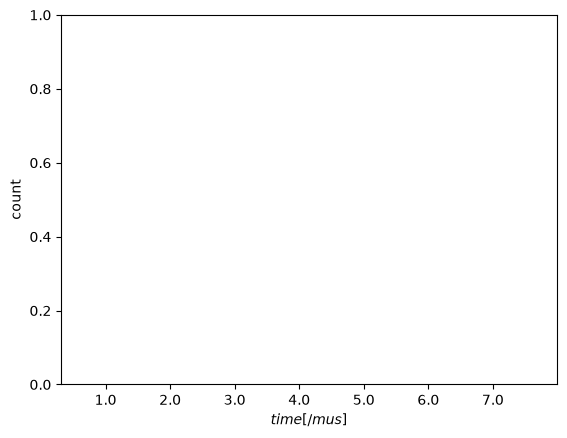

In [92]:

# cut dataset using data retrived in the "cuts" section
nf_g_refact = nf_g[(nf_g>0.3e-6) & (nf_g<8e-6)]
nf_p_refact = nf_p[(nf_p>0.3e-6) & (nf_p<8e-6)]





#! initial coefficients for the interpolation
exp_unif_args = {"freq_exp1": 0.9,  "tau1": TAU_MU , "A":0}

# interpolation (the output is a Minuit object)
g = dataset_analysis( nf_g_refact , exp_unif , bins = n_bins_nf , args=exp_unif_args)
g.limits["freq_exp1"] = (0,1) #type:ignore
# g.fixed["e"] = True

# calls Migrad, hesse and asymmetric errors, if the latter is not wanted add False keyword
end(g)

# interpolation (the output is a Minuit object)
p = dataset_analysis( nf_p_refact , exp_unif , bins = n_bins_nf , args=exp_unif_args)
p.limits["freq_exp1"] = (0,1) #type:ignore
# p.fixed["e"] = True

# calls Migrad, hesse and asymmetric errors, if the latter is not wanted add False keyword
end(p)




complete_nf= np.append( nf_g  , nf_p )
# cut dataset using data retrived in the "cuts" section
complete_nf_refact = complete_nf[(complete_nf>3e-7) & (complete_nf<8e-6)]

# interpolation (the output is a Minuit object)
comp = dataset_analysis( complete_nf_refact , exp_unif , bins = n_bins_nf , args=exp_unif_args)
comp.limits["freq_exp1"] = (0,1) #type:ignore
# comp.fixed["e"] = True

# calls Migrad, hesse and asymmetric errors, if the latter is not wanted add False keyword
end(comp)

nf = plots( complete_nf_refact, comp , r"$ time [ /mu s ] $" , "count")
a = 0

print(to_typst_table(comp))


### pics

In [93]:
fig_nf = nf.colour_plot(n_bins_nf , False , ["Dataset" , r"$ exp \tau = (2.10 \pm 0.035) \mu s $" , r"$uniform \nu = (2 \pm 1)\%$"])

fig_nf.savefig("Photo/interpolation/nf_components.pdf" , format="pdf")

274 274 274


<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_38692/1832583268.py:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel("time [$ \mu s $]")


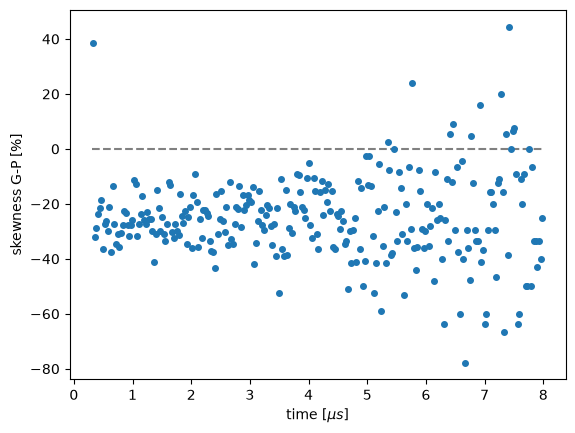

In [94]:
up = nf_g_refact * 1e6
down = nf_p_refact * 1e6


asym_void_range = (np.min(np.concatenate([up, down])), np.max(np.concatenate([up , down])))

count_u,edges = np.histogram( up , bins = n_bins_nf , range = asym_void_range)
count_d,edges = np.histogram( down , bins = n_bins_nf , range = asym_void_range)

bin_center = (edges[:-1] + edges[1:])/2


plt.errorbar( bin_center , (count_u - count_d)/(count_u + count_d)*100 , yerr = np.sqrt(count_u + count_d)/(len(up)+ len(down))*100 , xerr = 0.012e-6 , fmt="o" , markersize=4)
plt.hlines( 0 , xmin=asym_void_range[0] , xmax= asym_void_range[1] , linestyle="--" , color="grey")
plt.ylabel("skewness G-P [%]")
plt.xlabel("time [$ \mu s $]")

plt.savefig("Photo/interpolation/nf_skewness.pdf" , format="pdf")

<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_38692/2087814491.py:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axes[1].set_xlabel('Time $ [ \mu s] $')


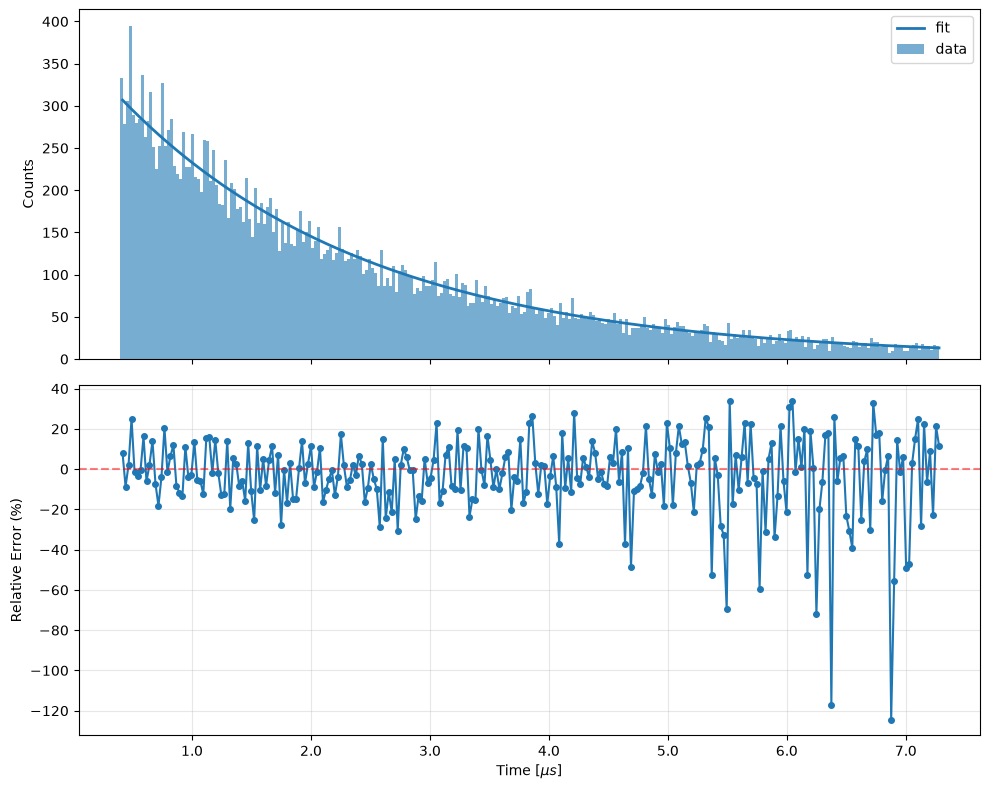

In [95]:
pic_data = complete_nf[(complete_nf > 0.4e-6)&(complete_nf < 7.3e-6)]
m = comp

count, edges = np.histogram(pic_data, n_bins_nf)
bin_centers = (edges[:-1] + edges[1:]) / 2
bin_widths = np.diff(edges)

# scale pdf to raw counts per bin
y_fit_counts = exp_unif_pdf(bin_centers, min(pic_data), max(pic_data), *m.values) * len(pic_data) * bin_widths

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# Top: histogram (raw counts) + fit (counts)
axes[0].bar(edges[:-1], count, width=bin_widths, alpha=0.6, label='data')
axes[0].plot(bin_centers, y_fit_counts, label='fit', linewidth=2)
axes[0].set_ylabel('Counts')
axes[0].legend()

# Bottom: relative errors (percent)
relative_errors = np.where(count > 0, (count - y_fit_counts) / count * 100, 0.0)
axes[1].plot(bin_centers, relative_errors, 'o-', markersize=4)
axes[1].axhline(0, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Time $ [ \mu s] $')
axes[1].set_ylabel('Relative Error (%)')
axes[1].grid(True, alpha=0.3)

axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x*1e6:.1f}'))

plt.tight_layout()
plt.savefig("Photo/interpolation/nf_interp.pdf" , format = "pdf")



## magnetic field interpolation

In [96]:
# cuts retrived from the "cuts" section
pv_g_refact = pv_g[(pv_g>0.3e-6) & (pv_g<8e-6)]
pv_p_refact = pv_p[(pv_p>0.3e-6) & (pv_p<8e-6)]


# initial parameters of the interpolation
exp_unif_args = {"freq_exp1": 0.9,  "tau1": TAU_MU , "A":0}

# interpolation (the output is a Minuit object)
g = dataset_analysis( pv_g_refact , exp_unif , bins = n_bins_pv , args=exp_unif_args)
g.limits["freq_exp1"] = (0,1) #type:ignore
# g.fixed["e"] = True

# calls Migrad, hesse and asymmetric errors, if the latter is not wanted add False keyword
end(g)

p = dataset_analysis( pv_p_refact , exp_unif , bins = n_bins_pv , args=exp_unif_args)
p.limits["freq_exp1"] = (0,1) #type:ignore
# p.fixed["e"] = True

# calls Migrad, hesse and asymmetric errors, if the latter is not wanted add False keyword
end(p)




complete_pv= np.append( pv_g  , pv_p )
# cuts retrived from the "cuts" section
complete_pv_refact = complete_pv[(complete_pv>3e-7)& (complete_pv<8e-6)]

# interpolation (the output is a Minuit object)
comp = dataset_analysis( complete_pv_refact , exp_unif , bins = n_bins_pv , args=exp_unif_args)
comp.limits["freq_exp1"] = (0,1) #type:ignore
# comp.fixed["e"] = True

# calls Migrad, hesse and asymmetric errors, if the latter is not wanted add False keyword
end(comp)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 139.6 (χ²/ndof = 1.1)      │              Nfcn = 120              │
│ EDM = 3.18e-05 (Goal: 0.0002)    │            time = 0.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name      │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp1 │   0.941   │   0.010   │   -0.009   │   0.010    │    0    │    1    │       │
│ 1 │ tau1      │ 1.978e-6  │ 0.031e-6  │ -0.031e-6  │  0.032e-6  │         │         │       │
│ 2 │ A         │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┐
│          │       freq_exp1       │         tau1          │
├──────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.009   │   0.010   │ -0.031e-6 │ 0.032e-6  │
│  Valid   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┘
┌───────────┬────────────────────────────────────────┐
│           │    freq_exp1         tau1            A │
├───────────┼────────────────────────────────────────┤
│ freq_exp1 │     9.09e-05 256.9264e-12            0 │
│      tau1 │ 256.9264e-12     9.81e-16        0e-15 │
│         A │            0        0e-15            0 │
└───────────┴────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 183.2 (χ²/ndof = 1.5)      │              Nfcn = 128              │
│ EDM = 6.58e-05 (Goal: 0.0002)    │            time = 0.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name      │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp1 │   0.970   │   0.007   │   -0.007   │   0.007    │    0    │    1    │       │
│ 1 │ tau1      │ 2.060e-6  │ 0.023e-6  │ -0.023e-6  │  0.024e-6  │         │         │       │
│ 2 │ A         │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┐
│          │       freq_exp1       │         tau1          │
├──────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.007   │   0.007   │ -0.023e-6 │ 0.024e-6  │
│  Valid   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┘
┌───────────┬────────────────────────────────────────┐
│           │    freq_exp1         tau1            A │
├───────────┼────────────────────────────────────────┤
│ freq_exp1 │     4.95e-05 143.0282e-12            0 │
│      tau1 │ 143.0282e-12     5.48e-16            0 │
│         A │            0            0            0 │
└───────────┴────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 295.2 (χ²/ndof = 2.3)      │              Nfcn = 116              │
│ EDM = 3.24e-08 (Goal: 0.0002)    │            time = 0.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name      │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ freq_exp1 │   0.966   │   0.006   │   -0.006   │   0.006    │    0    │    1    │       │
│ 1 │ tau1      │ 2.065e-6  │ 0.019e-6  │ -0.019e-6  │  0.019e-6  │         │         │       │
│ 2 │ A         │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┐
│          │       freq_exp1       │         tau1          │
├──────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.006   │   0.006   │ -0.019e-6 │ 0.019e-6  │
│  Valid   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┘
┌───────────┬─────────────────────────────────────┐
│           │   freq_exp1        tau1           A │
├───────────┼─────────────────────────────────────┤
│ freq_exp1 │    3.31e-05 95.8886e-12           0 │
│      tau1 │ 95.8886e-12    3.68e-16           0 │
│         A │           0           0           0 │
└───────────┴─────────────────────────────────────┘

## differences

In [97]:
error_prop = lambda count_up , count_down: 2 * np.sqrt( (count_up**2 * count_down + count_up * count_down **2)/( count_up + count_down)**4)

In [98]:

range_pv = (3e-7 , 8e-6)

diff_bins = 6

count_g, edges_g = np.histogram(pv_g_refact, diff_bins, range=range_pv)
count_p, _ = np.histogram(pv_p_refact, diff_bins, range=range_pv)

count_g_nf, edges_nf = np.histogram(nf_g_refact, diff_bins, range=range_pv)
count_p_nf, _ = np.histogram(nf_p_refact, diff_bins, range=range_pv)

edges_center = (edges_g[1:] + edges_g[:-1]) / 2

asym_g = (count_g - count_p) / (count_g + count_p)
asym_nf = (count_g_nf - count_p_nf) / (count_g_nf + count_p_nf)



errors = [ np.sqrt(np.power(error_prop(count_g[i] , count_p[i]) , 2) + np.power(error_prop(count_g_nf[i] , count_p_nf[i]) , 2)) for i in range(len(count_g))]





fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=edges_center,
        y=(asym_g - asym_nf),
        mode="markers",
        error_y=dict(type="data", array=errors, visible=True),
        name="diff",
    )
)
fig.update_layout(
    xaxis_title="time",
    yaxis_title="percentage asymmetry",
    showlegend=True
)
fig.show()

### interpolation

In [121]:
def parity_violation_model( x , A , phi , omega , c): 
    return A*np.sin( omega * x + phi) + c

def parity_conservation_model( x , c ):
    return c * np.ones_like(x)

range_pv = (3e-7 , 8e-6)

diff_bins = 6

count_g, edges_g = np.histogram(pv_g_refact, diff_bins, range=range_pv)
count_p, _ = np.histogram(pv_p_refact, diff_bins, range=range_pv)

count_g_nf, edges_nf = np.histogram(nf_g_refact, diff_bins, range=range_pv)
count_p_nf, _ = np.histogram(nf_p_refact, diff_bins, range=range_pv)

edges_center = (edges_g[1:] + edges_g[:-1]) / 2

asym_g = (count_g - count_p) / (count_g + count_p)
asym_nf = (count_g_nf - count_p_nf) / (count_g_nf + count_p_nf)

errors = [ np.sqrt(np.power(error_prop(count_g[i] , count_p[i]) , 2) + np.power(error_prop(count_g_nf[i] , count_p_nf[i]) , 2)) for i in range(len(count_g))]


ls = LeastSquares( edges_center , asym_g - asym_nf , errors , parity_violation_model)
parity_violation = Minuit( ls  , A = 1 , omega = 1e6 , phi = 0 , c = np.mean(asym_g - asym_nf))
parity_violation.fixed["c"] = True
parity_violation.limits["A" , "omega" , "phi"] = (0 , None)
parity_violation.migrad()
parity_violation.hesse()

display( parity_violation)



ls = LeastSquares( edges_center , asym_g - asym_nf , errors , parity_conservation_model)
parity_conservation = Minuit( ls , c = np.mean(asym_g - asym_nf))
parity_conservation.migrad()
parity_conservation.hesse()

display(parity_conservation)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.569 (χ²/ndof = 0.5)      │              Nfcn = 163              │
│ EDM = 0.000183 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A     │   0.012   │   0.009   │            │            │    0    │         │       │
│ 1 │ phi   │    0.0    │    1.2    │            │            │    0    │         │       │
│ 2 │ omega │1.3648377e6│0.0000009e6│            │            │    0    │         │       │
│ 3 │ c     │ -63.4e-3  │  0.6e-3   │            │            │         │         │  yes  │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬─────────────────────────────────────┐
│       │        A      phi    omega        c │
├───────┼─────────────────────────────────────┤
│     A │ 7.46e-05       -0        0        0 │
│   phi │       -0 2.57e-08        0        0 │
│ omega │        0        0    0.759      0.0 │
│     c │        0        0      0.0        0 │
└───────┴─────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.444 (χ²/ndof = 0.7)      │              Nfcn = 16               │
│ EDM = 2.91e-21 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ c    │  -0.061   │   0.007   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬──────────┐
│   │        c │
├───┼──────────┤
│ c │ 4.62e-05 │
└───┴──────────┘

### pics

<>:38: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:38: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_38692/2488821186.py:38: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_xlabel("time [$\mu s$]")


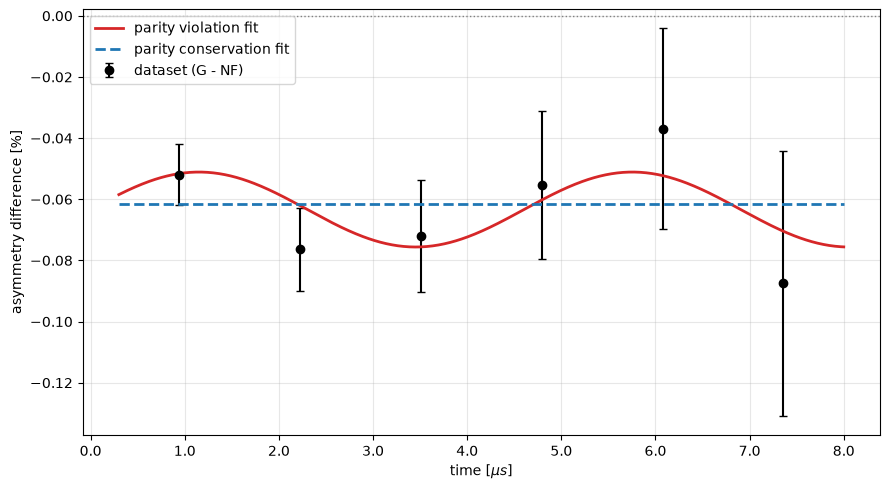

In [127]:
x = edges_center
y = asym_g - asym_nf
yerr = errors

x_fit = np.linspace(range_pv[0], range_pv[1], 500)

y_violation = parity_violation_model(
    x_fit,
    parity_violation.values["A"],
    parity_violation.values["phi"],
    parity_violation.values["omega"],
    parity_violation.values["c"],
)

y_conservation = parity_conservation_model(
    x_fit,
    parity_conservation.values["c"],
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(
    x,
    y,
    yerr=yerr,
    fmt="o",
    ms=6,
    capsize=3,
    color="black",
    label="dataset (G - NF)",
)

ax.plot(x_fit, y_violation, "-", lw=2, color="tab:red", label="parity violation fit")
ax.plot(x_fit, y_conservation, "--", lw=2, color="tab:blue", label="parity conservation fit")

ax.axhline(0, color="gray", linestyle=":", linewidth=1)

ax.set_xlabel("time [$\mu s$]")
ax.set_ylabel("asymmetry difference [%]")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x,p: f'{x*1e6:.1f}'))
ax.legend()
plt.tight_layout()
fig.savefig("Photo/interpolation/parity_violation.pdf" , format="pdf")
plt.show()

# Chi^2 analysis


## binning


### void


In [100]:
min_bin_range = 50
max_bin_range = 300
step_bin = 2
range_bins = np.arange(min_bin_range , max_bin_range , step_bin , dtype=int)






exp_args = {"freq_exp1": 0.9,"tau1": TAU_MU , "A":0}

void_data_chi:np.ndarray = data[(data>2e-7)&(data<7e-6)]

model = model_function_builder( exp_unif , void_data_chi)
p_value_list = []
void_chi2_list = []
err_list = []
chi2_list = []
for bin in tqdm(range_bins):
    n = dataset_analysis( void_data_chi , exp_unif , bins = int(bin) , args=exp_args , model_function=model)
    n.migrad()
    n.hesse()
    p_value_list.append(1 - chi2.cdf(n.fval, df=n.ndof))
    void_chi2_list.append(n.fval/n.ndof)
    err_list.append( n.errors[1])
    if n.fval == None:
        raise KeyError(f"interpolation failed at bin: {bin}")
    if not n.valid:
        print("interpolation failed F")
    chi2_list.append(n.fval/n.ndof)


  0%|          | 0/125 [00:00<?, ?it/s]

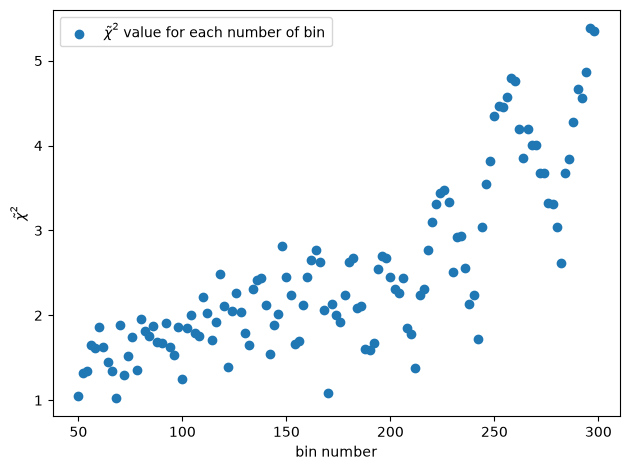

In [101]:
fig, ax = plt.subplots(1,1)
ax.scatter( range_bins , void_chi2_list , label = r"$ \tilde{\chi}^2 $ value for each number of bin")
ax.set_xlabel("bin number")
ax.set_ylabel(r"$\tilde{\chi}^2$")
ax.legend()
fig.tight_layout()
fig.savefig("Photo/interpolation/void_bins.pdf" , format="pdf")

fig = go.Figure()
fig.add_trace(go.Scatter(x=range_bins, y=void_chi2_list, mode='markers', name=r'$ \tilde{\chi}^2 $ value for each number of bin'))
fig.update_layout(
    xaxis_title="bin number",
    yaxis_title=r"$\tilde{\chi}^2$",
    showlegend=True
)
fig.show()

### NaCl


In [102]:
min_bin_range = 100
max_bin_range = 400
step_bin = 2
range_bins = np.arange(min_bin_range , max_bin_range , step_bin , dtype=int)


double_exp_unif_args = {"freq_exp": 0.9, "relative_freq":0.1,  "tau1": tau_hat , "tau2":TAU_NaCl, "A":0}

model = model_function_builder( double_exp_unif , complete_salt_refact)

p_value_list = []
na_chi2_list = []
err1_list = []
err2_list = []
chi2_list = []
for bin in tqdm(range_bins):
    n = dataset_analysis( complete_salt_refact , double_exp_unif , bins = bin , args=double_exp_unif_args , model_function=model)
    n.limits["freq_exp" , "relative_freq"] = (0.0 , 1.0)#type:ignore
    n.migrad()
    n.hesse()
    p_value_list.append(1 - chi2.cdf(n.fval, df=n.ndof))
    na_chi2_list.append(n.fval/n.ndof)
    err1_list.append( n.errors[2])
    err2_list.append( n.errors[3])
    if n.fval == None:
        raise KeyError(f"interpolation failed at bin: {bin}")
    chi2_list.append(n.fval/n.ndof)



  0%|          | 0/150 [00:00<?, ?it/s]

<>:2: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:2: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_38692/1885199059.py:2: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  ax.scatter( range_bins , na_chi2_list , label = "$\chi^2$ value for each number of bin")


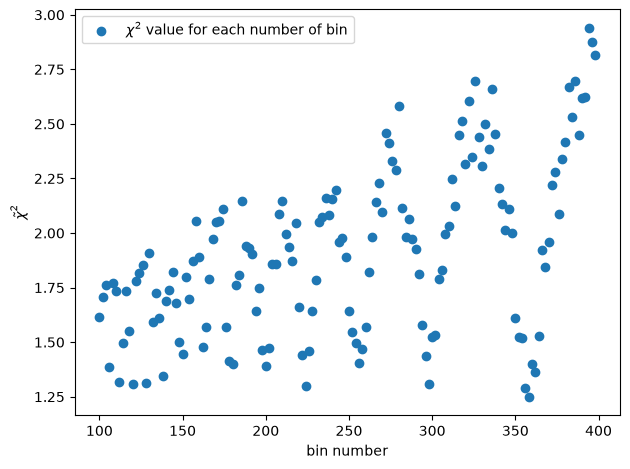

In [103]:
fig, ax = plt.subplots(1,1)
ax.scatter( range_bins , na_chi2_list , label = "$\chi^2$ value for each number of bin")
ax.set_xlabel("bin number")
ax.set_ylabel(r"$\tilde{\chi}^2$")
ax.legend()
fig.tight_layout()
fig.savefig("Photo/interpolation/na_bins.pdf" , format="pdf")


fig = go.Figure()
fig.add_trace(go.Scatter(x=range_bins, y=na_chi2_list, mode='markers', name=r'$\tilde{\chi}^2$ value for each number of bin'))
fig.update_layout(
    xaxis_title="bin number",
    yaxis_title=r"$\tilde{\chi}^2$",
    showlegend=True
)
fig.show()

### Al


In [104]:
min_bin_range = 100
max_bin_range = 350
step_bin = 2
range_bins = np.arange(min_bin_range , max_bin_range , step_bin , dtype=int)


double_exp_unif_args = {"freq_exp": 0.9, "relative_freq":0.1,  "tau1": tau_hat , "tau2":TAU_NaCl, "A":0}

model = model_function_builder( double_exp_unif , complete_al_refact)

p_value_list = []
al_chi2_list = []
err1_list = []
err2_list = []
chi2_list = []
for bin in tqdm(range_bins):
    n = dataset_analysis( complete_al_refact , double_exp_unif , bins = bin , args=double_exp_unif_args , model_function = model)
    n.limits["freq_exp" , "relative_freq"] = (0.0 , 1.0)#type:ignore
    n.migrad()
    n.hesse()
    p_value_list.append(1 - chi2.cdf(n.fval, df=n.ndof))
    al_chi2_list.append(n.fval/n.ndof)
    err1_list.append( n.errors[2])
    err2_list.append( n.errors[3])
    if n.fval == None:
        raise KeyError(f"interpolation failed at bin: {bin}")
    chi2_list.append(n.fval/n.ndof)



  0%|          | 0/125 [00:00<?, ?it/s]

<>:2: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:2: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_38692/1003939174.py:2: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  ax.scatter( range_bins , al_chi2_list , label = "$\chi^2 $ value for each number of bin")


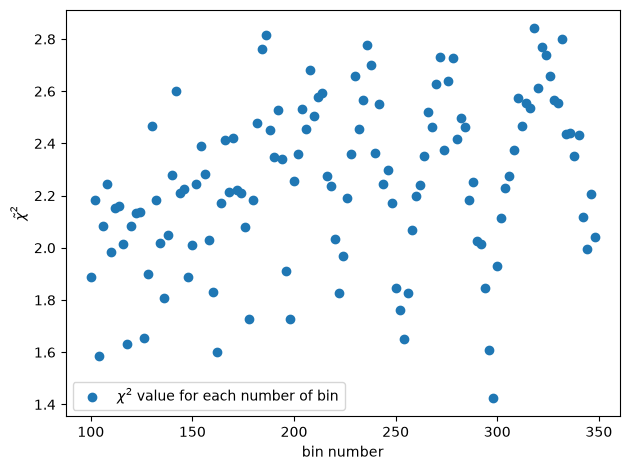

In [105]:
fig, ax = plt.subplots(1,1)
ax.scatter( range_bins , al_chi2_list , label = "$\chi^2 $ value for each number of bin")
ax.set_xlabel("bin number")
ax.set_ylabel(r"$\tilde{\chi}^2$")
ax.legend()
fig.tight_layout()
fig.savefig("Photo/interpolation/al_bins.pdf" , format="pdf")

fig = go.Figure()
fig.add_trace(go.Scatter(x=range_bins, y=al_chi2_list, mode='markers', name=r'$\tilde{\chi}^2$ value for each number of bin'))
fig.update_layout(
    xaxis_title="bin number",
    yaxis_title=r"$\tilde{\chi}^2$",
    showlegend=True
)
fig.show()

### parity violation

In [106]:
min_bin_range = 10
max_bin_range = 300
step_bin = 2
range_bins = np.arange(min_bin_range, max_bin_range, step_bin, dtype=int)

exp_args = {"freq_exp1": 0.9, "tau1": TAU_MU, "A": 0}

nf_data_chi: np.ndarray = complete_nf[(complete_nf>0.3e-6) & (complete_nf<8e-6)]

model = model_function_builder( exp_unif , nf_data_chi)
nf_p_value_list = []
nf_chi2_list = []
nf_err_list = []
chi2_list = []

for bin in tqdm(range_bins):
    n = dataset_analysis(nf_data_chi, exp_unif, bins=int(bin), args=exp_args , model_function=model)
    n.migrad()
    n.hesse()
    nf_p_value_list.append(1 - chi2.cdf(n.fval, df=n.ndof))
    nf_chi2_list.append(n.fval / n.ndof)
    nf_err_list.append(n.errors[1])
    if n.fval == None:
        raise KeyError(f"interpolation failed at bin: {bin}")
    if not n.valid:
        print("interpolation failed F")
    chi2_list.append(n.fval / n.ndof)

  0%|          | 0/145 [00:00<?, ?it/s]

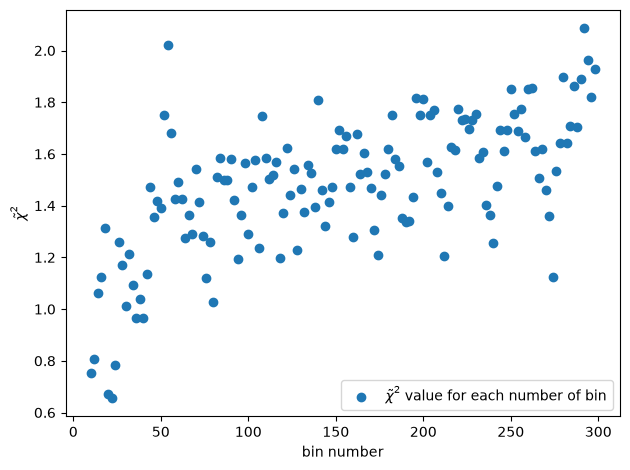

In [107]:
fig, ax = plt.subplots(1,1)
ax.scatter( range_bins , nf_chi2_list , label = r"$\tilde{\chi}^2$ value for each number of bin")
ax.set_xlabel("bin number")
ax.set_ylabel(r"$\tilde{\chi}^2$")
ax.legend()
fig.tight_layout()
fig.savefig("Photo/interpolation/nf_bins.pdf" , format="pdf")

fig = go.Figure()
fig.add_trace(go.Scatter(x=range_bins, y=nf_chi2_list, mode='markers', name=r'$\tilde{\chi}^2$ value for each number of bin'))
fig.update_layout(
    xaxis_title="bin number",
    yaxis_title=r"$\tilde{\chi}^2$",
    showlegend=True
)
fig.show()

In [108]:
min_bin_range = 10
max_bin_range = 300
step_bin = 2
range_bins = np.arange(min_bin_range , max_bin_range , step_bin , dtype=int)


exp_args = {"freq_exp1": 0.9,"tau1": TAU_MU , "A":0}

pv_data_chi:np.ndarray = complete_pv[(complete_pv>0.3e-6) & (complete_pv<8e-6)]
model = model_function_builder( exp_unif , pv_data_chi) 
pv_p_value_list = []
pv_chi2_list = []
err_list = []
chi2_list = []
for bin in tqdm(range_bins):
    n = dataset_analysis(pv_data_chi , exp_unif , bins = int(bin) , args=exp_args , model_function = model)
    n.migrad()
    n.hesse()
    pv_p_value_list.append(1 - chi2.cdf(n.fval, df=n.ndof))
    pv_chi2_list.append(n.fval/n.ndof)
    err_list.append( n.errors[1])
    if n.fval == None:
        raise KeyError(f"interpolation failed at bin: {bin}")
    if not n.valid:
        print("interpolation failed F")
    chi2_list.append(n.fval/n.ndof)

  0%|          | 0/145 [00:00<?, ?it/s]

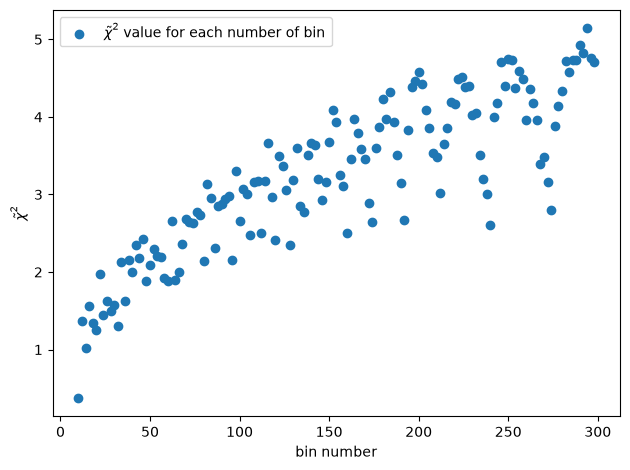

In [109]:
fig, ax = plt.subplots(1,1)
ax.scatter( range_bins , pv_chi2_list , label = r"$\tilde{\chi}^2$ value for each number of bin")
ax.set_xlabel("bin number")
ax.set_ylabel(r"$\tilde{\chi}^2$")
ax.legend()
fig.tight_layout()
fig.savefig("Photo/interpolation/pv_bins.pdf" , format="pdf")

fig = go.Figure()
fig.add_trace(go.Scatter(x=range_bins, y=pv_chi2_list, mode='markers', name=r'$\tilde{\chi}^2$ value for each number of bin'))
fig.update_layout(
    xaxis_title="bin number",
    yaxis_title=r"$\tilde{\chi}^2$",
    showlegend=True
)
fig.show()

## cuts


### void


In [110]:
start_cut_range = (1e-8,1e-6)
end_cut_range = (5e-6,8.5e-6)



errListIni=[]
void_chiListIni = []

edited_data = data[(data<5e-6)]
for i in tqdm(np.linspace(*start_cut_range)):
    void_data_ini:np.ndarray = edited_data[(edited_data>=i)]
    void_ini_cut = dataset_analysis( void_data_ini , exp_unif , bins = n_bins_void , args={"freq_exp1": 0.9,"tau1": TAU_MU , "A":0})
    void_ini_cut.limits["freq_exp1"] = (0,1)
    void_ini_cut.limits["tau1"] = (2e-6,3e-6)
    void_ini_cut.migrad()
    if void_ini_cut.fval == None:
        raise EnvironmentError(f"interpolation failed at {i}")
    void_chiListIni.append(void_ini_cut.fval/void_ini_cut.ndof)
    errListIni.append(void_ini_cut.errors["tau1"])
    
errListEnd=[]
void_chiListEnd = []
edited_data = data[(data>5e-7)]
for i in tqdm(np.linspace(*end_cut_range)):
    void_data_end:np.ndarray = edited_data[(edited_data<=i)]
    void_end_cut = dataset_analysis( void_data_end , exp_unif , bins = n_bins_void , args={"freq_exp1": 0.9,"tau1": TAU_MU , "A":0})
    void_end_cut.limits["freq_exp1"] = (0,1)
    void_end_cut.limits["tau1"] = (2e-6,3e-6)
    void_end_cut.migrad()
    if void_end_cut.fval == None:
        raise EnvironmentError(f"interpolation failed at {i}")
    void_chiListEnd.append(void_end_cut.fval/void_end_cut.ndof)
    errListEnd.append(void_end_cut.errors["tau1"])
    
    


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:17: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:18: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:19: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:21: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:17: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences wil

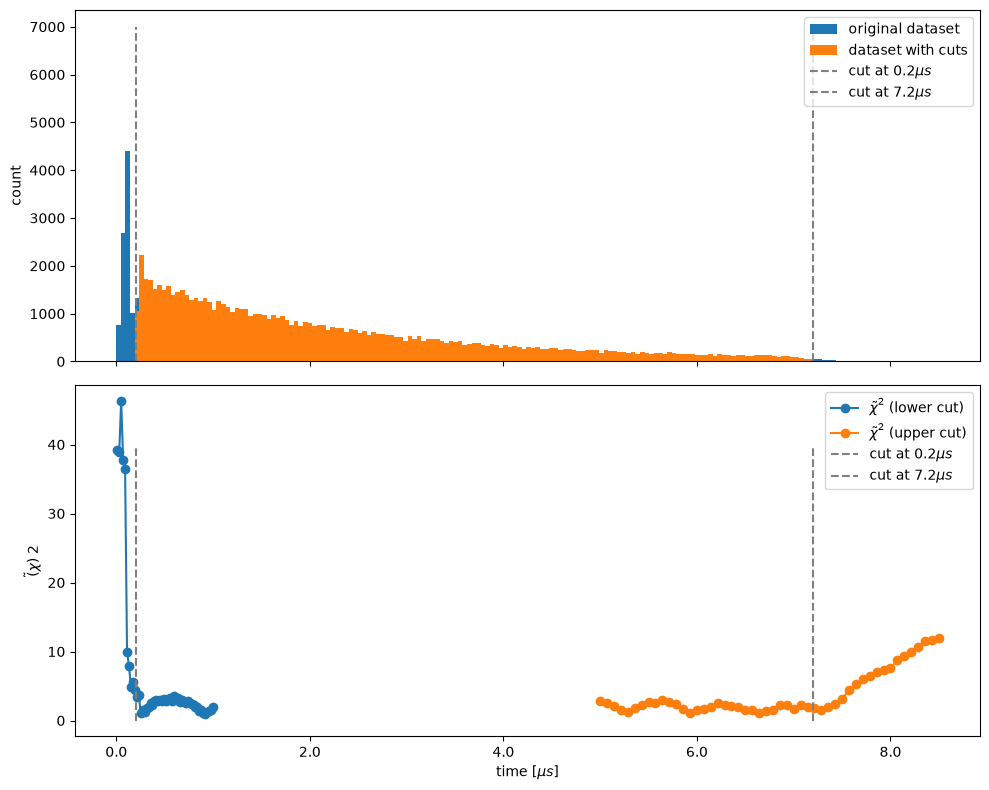

In [111]:
edited_data = data[(data>0.2e-6) & (data<7.2e-6)]
full_data = data



fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].hist(full_data , bins=n_bins_void , range = (0,8e-6) , label = "original dataset")
axes[0].hist(edited_data , bins=n_bins_void , range = (0,8e-6) , label = "dataset with cuts")


axes[1].plot(np.linspace(*start_cut_range), void_chiListIni, "o-", label=r"$\tilde{\chi}^2$ (lower cut)")
axes[1].plot(np.linspace(*end_cut_range), void_chiListEnd, "o-", label=r"$\tilde{\chi}^2$ (upper cut)")

axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x*1e6:.1f}'))
axes[0].vlines(0.2e-6, 0, 7000, colors="gray", linestyle = "--", label="cut at $ 0.2 \mu s $")
axes[0].vlines(7.2e-6, 0, 7000, colors="gray", linestyle = "--", label="cut at $ 7.2 \mu s $")
axes[1].vlines(0.2e-6, 0, 40, colors="gray", linestyle = "--", label="cut at $ 0.2 \mu s $")
axes[1].vlines(7.2e-6, 0, 40, colors="gray", linestyle = "--", label="cut at $ 7.2 \mu s $")

axes[1].set_xlabel("time $ [ \mu s] $")
axes[1].set_ylabel(r"$ \tilde(\chi)^ 2$")
axes[0].set_ylabel("count")

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.savefig("Photo/interpolation/void_cuts.pdf" , format = "pdf")


### Na


In [112]:
start_cut_range = (1e-6,1e-8)
end_cut_range = (5e-6,max(complete_salt))
print(n_bins)
errListIni=[]
na_chiListIni = []


double_exp_unif_args = {"freq_exp": 0.9, "relative_freq":0.1,  "tau1": tau_hat , "tau2":TAU_NaCl, "A":0}


edited_data = complete_salt[(complete_salt<7e-6)]
for i in tqdm(np.linspace(*start_cut_range)):
    na_data_ini:np.ndarray = edited_data[(edited_data>=i)]
    na_ini_cut = dataset_analysis( na_data_ini , double_exp_unif , bins = n_bins_na , args=double_exp_unif_args)
    na_ini_cut.limits["freq_exp" , "relative_freq"] = (0.0 , 1.0)#type:ignore
    na_ini_cut.limits["tau1"] = (2e-6,3e-6)
    na_ini_cut.migrad()
    if na_ini_cut.fval == None:
        raise EnvironmentError(f"interpolation failed at {i}")
    na_chiListIni.append(na_ini_cut.fval/na_ini_cut.ndof)
    errListIni.append(na_ini_cut.errors["tau1"])
    
errListEnd=[]
na_chiListEnd = []
edited_data = complete_salt[(complete_salt>2e-7)]
for i in tqdm(np.linspace(*end_cut_range)):
    na_data_end:np.ndarray = edited_data[(edited_data<=i)]
    na_end_cut = dataset_analysis( na_data_end , double_exp_unif , bins = n_bins_na , args=double_exp_unif_args)
    na_end_cut.limits["freq_exp" , "relative_freq"] = (0.0 , 1.0)#type:ignore
    na_end_cut.limits["tau1"] = (2e-6,3e-6)
    na_end_cut.migrad()
    if na_end_cut.fval == None:
        raise EnvironmentError(f"interpolation failed at {i}")
    na_chiListEnd.append(na_end_cut.fval/na_end_cut.ndof)
    errListEnd.append(na_end_cut.errors["tau1"])

67


  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_38692/2463879765.py:20: RuntimeWarning: divide by zero encountered in divide
  return  N * freq_exp * ((1 - relative_freq)* exp1.cdf(x)/normalization( exp1 , min , max) + (relative_freq) * exp2.cdf(x)/normalization(exp2, min , max)) + (1 - freq_exp) * N * (uniform.cdf(x, min, max))
/home/feBolde/coding/.venvs/pyvenv/lib64/python3.14/site-packages/numpy/lib/_function_base_impl.py:1540: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])


  0%|          | 0/50 [00:00<?, ?it/s]

<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:18: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:18: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_38692/1706348744.py:16: SyntaxWarning: "\m" is an invalid esc

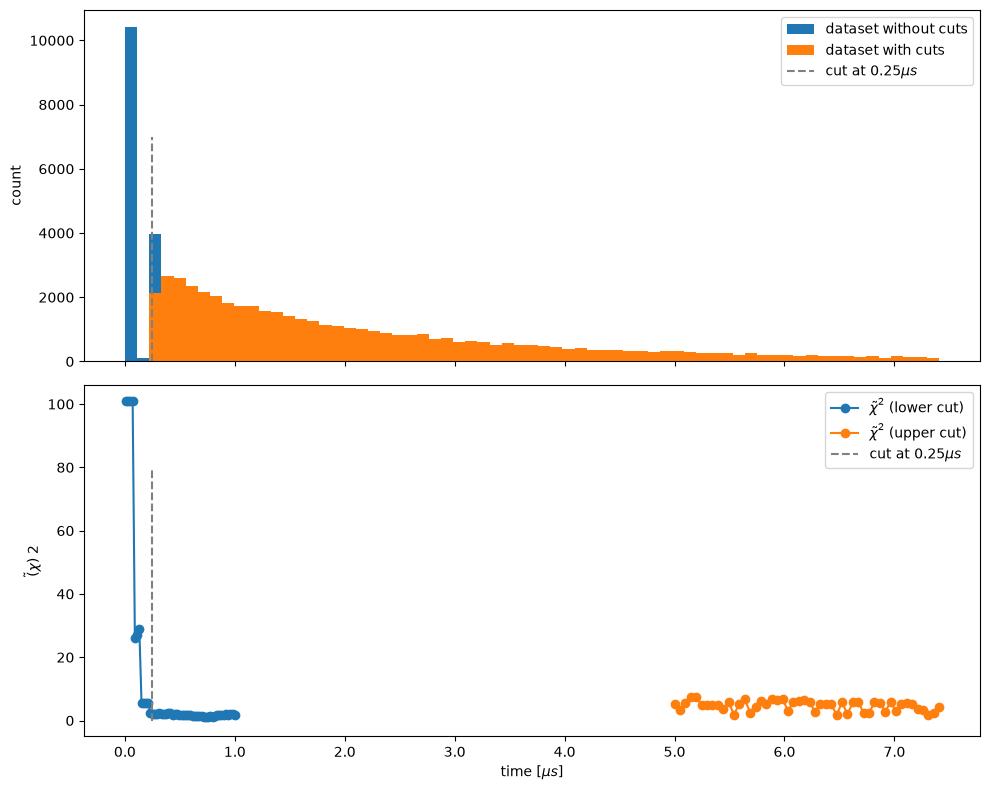

In [113]:
edited_data = complete_salt[(complete_salt>0.25e-6)]
full_data = complete_salt



fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

count1, edges1, patches1 = axes[0].hist(full_data, bins=n_bins, range=(0,max(complete_salt)), label="dataset without cuts")
count, edges, patches = axes[0].hist(edited_data, bins=n_bins, range=(0,max(complete_salt)), label="dataset with cuts")

axes[1].plot(np.linspace(*start_cut_range), na_chiListIni, "o-", label=r"$\tilde{\chi}^2$ (lower cut)")
axes[1].plot(np.linspace(*end_cut_range), na_chiListEnd, "o-", label=r"$\tilde{\chi}^2$ (upper cut)")

axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x*1e6:.1f}'))

axes[0].vlines(0.25e-6, 0, 7000, colors="gray", linestyle = "--", label="cut at $ 0.25 \mu s $")

axes[1].vlines(0.25e-6, 0, 80, colors="gray", linestyle = "--", label="cut at $ 0.25 \mu s $")

axes[0].legend()
axes[1].legend()
axes[1].set_xlabel("time $ [ \mu s] $")
axes[1].set_ylabel(r"$ \tilde(\chi)^ 2$")
axes[0].set_ylabel("count")

plt.tight_layout()
plt.savefig("Photo/interpolation/na_cuts.pdf" , format = "pdf")


### Al


In [114]:
start_cut_range = (1e-8,1e-6)
end_cut_range = (5e-6,max(complete_al))
print(n_bins)
errListIni=[]
al_chiListIni = []

double_exp_unif_args = {"freq_exp": 0.9, "relative_freq":0.1,  "tau1": tau_hat , "tau2":TAU_Al, "A":0}

edited_data = complete_al[(complete_al<8e-6)]
for i in tqdm(np.linspace(*start_cut_range)):
    al_data_ini: np.ndarray = edited_data[(edited_data >= i)]
    al_ini_cut = dataset_analysis(al_data_ini, double_exp_unif, bins=n_bins_al, args=double_exp_unif_args)
    al_ini_cut.limits["freq_exp" , "relative_freq"] = (0.0 , 1.0)#type:ignore
    al_ini_cut.limits["tau1"] = (2e-6, 3e-6)
    al_ini_cut.migrad()
    if al_ini_cut.fval is None:
        raise EnvironmentError(f"interpolation failed at {i}")
    al_chiListIni.append(al_ini_cut.fval / al_ini_cut.ndof)
    errListIni.append(al_ini_cut.errors["tau1"])

errListEnd = []
al_chiListEnd = []
edited_data = complete_al[(complete_al > 2e-7)]
for i in tqdm(np.linspace(*end_cut_range)):
    al_data_end: np.ndarray = edited_data[(edited_data <= i)]
    al_end_cut = dataset_analysis(al_data_end, double_exp_unif, bins=n_bins, args=double_exp_unif_args)
    al_end_cut.limits["freq_exp" , "relative_freq"] = (0.0 , 1.0)#type:ignore
    al_end_cut.limits["tau1"] = (2e-6, 3e-6)
    al_end_cut.migrad()
    if al_end_cut.fval is None:
        raise EnvironmentError(f"interpolation failed at {i}")
    al_chiListEnd.append(al_end_cut.fval / al_end_cut.ndof)
    errListEnd.append(al_end_cut.errors["tau1"])
    if al_end_cut.fval == None:
        raise EnvironmentError(f"interpolation failed at {i}")
    errListEnd.append(void_end_cut.errors["tau1"])

67


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

<>:18: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:18: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_38692/1071701548.py:18: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axes[1].set_xlabel("time $ [ \mu s] $")


7.228e-06
50 50


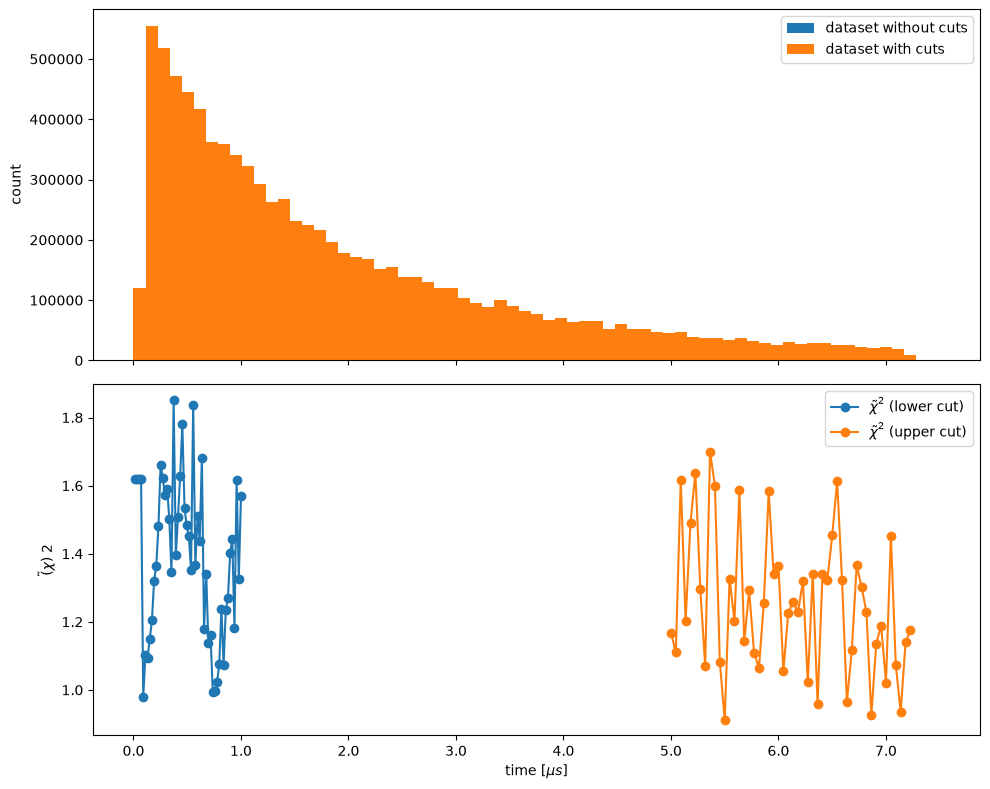

In [115]:
edited_data = complete_al
full_data = complete_al

print(max(complete_al))

print(len(al_chiListIni) , len(al_chiListEnd))

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].hist(full_data , bins=n_bins , range = (0,7.5e-6) , density = True , label = "dataset without cuts")
axes[0].hist(edited_data , bins=n_bins , range = (0,7.5e-6) , density = True, label = "dataset with cuts")


axes[1].plot(np.linspace(*start_cut_range), al_chiListIni, "o-", label=r"$\tilde{\chi}^2$ (lower cut)")
axes[1].plot(np.linspace(*end_cut_range), al_chiListEnd, "o-", label=r"$\tilde{\chi}^2$ (upper cut)")

axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x*1e6:.1f}'))
axes[1].set_xlabel("time $ [ \mu s] $")
axes[1].set_ylabel(r"$ \tilde(\chi)^ 2$")
axes[0].set_ylabel("count")



axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.savefig("Photo/interpolation/al_cuts.pdf" , format = "pdf")


### parity violation

In [116]:
start_cut_range = (1e-8,1e-6)
end_cut_range = (5e-6,8e-6)
print(n_bins)
errListIni=[]
nf_chiListIni = []

edited_data = complete_nf[(complete_nf<5e-6)]
for i in tqdm(np.linspace(*start_cut_range)):
    nf_data_ini:np.ndarray = edited_data[(edited_data>=i)]
    nf_ini_cut = dataset_analysis( nf_data_ini , exp , bins = n_bins_nf , args={"tau1": TAU_MU , "A":0})
    # nf_ini_cut.limits["freq_exp1"] = (0,1)
    nf_ini_cut.limits["tau1"] = (2e-6,3e-6)
    nf_ini_cut.migrad()
    if nf_ini_cut.fval == None:
        raise EnvironmentError(f"interpolation failed at {i}")
    nf_chiListIni.append(nf_ini_cut.fval/nf_ini_cut.ndof)
    errListIni.append(nf_ini_cut.errors["tau1"])
    
errListEnd=[]
nf_chiListEnd = []
edited_data = complete_nf[(complete_nf>5e-7)]
for i in tqdm(np.linspace(*end_cut_range)):
    nf_data_end:np.ndarray = edited_data[(edited_data<=i)]
    nf_end_cut = dataset_analysis( nf_data_end , exp , bins = n_bins_nf , args={"tau1": TAU_MU , "A":0})
    # nf_end_cut.limits["freq_exp1"] = (0,1)
    nf_end_cut.limits["tau1"] = (2e-6,3e-6)
    nf_end_cut.migrad()
    if nf_end_cut.fval == None:
        raise EnvironmentError(f"interpolation failed at {i}")
    nf_chiListEnd.append(nf_end_cut.fval/nf_end_cut.ndof)

67


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

<>:18: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:18: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_38692/831210423.py:18: SyntaxWarning: "\m" is an invalid esca

50 50


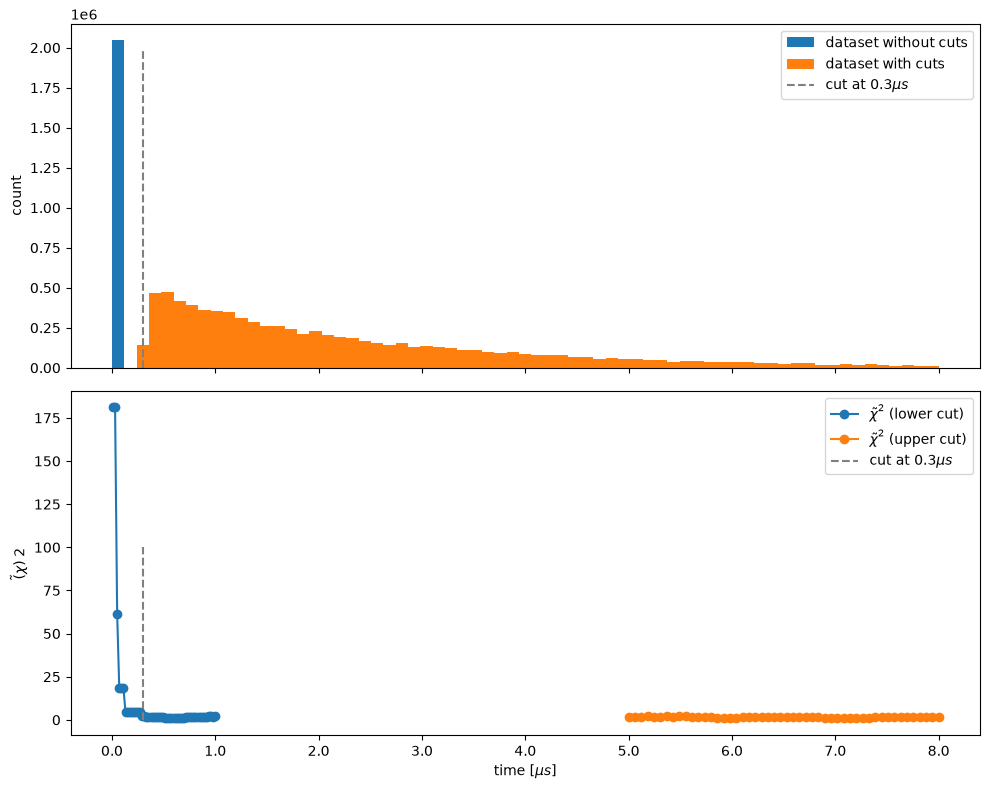

In [117]:
edited_data = complete_nf[(complete_nf>0.3e-6) & (complete_nf<8e-6)]
full_data = complete_nf



print(len(nf_chiListIni) , len(nf_chiListEnd))

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].hist(full_data , bins=n_bins , range = (0,8e-6) , density = True , label = "dataset without cuts")
axes[0].hist(edited_data , bins=n_bins , range = (0,8e-6) , density = True, label = "dataset with cuts")


axes[1].plot(np.linspace(*start_cut_range), nf_chiListIni, "o-", label=r"$\tilde{\chi}^2$ (lower cut)")
axes[1].plot(np.linspace(*end_cut_range), nf_chiListEnd, "o-", label=r"$\tilde{\chi}^2$ (upper cut)")

axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x*1e6:.1f}'))
axes[1].set_xlabel("time $ [ \mu s] $")
axes[1].set_ylabel(r"$ \tilde(\chi)^ 2$")
axes[0].set_ylabel("count")

axes[0].vlines(0.3e-6, 0, 2e6, colors="gray", linestyle = "--", label="cut at $ 0.3 \mu s $")
axes[1].vlines(0.3e-6, 0, 100, colors="gray", linestyle = "--", label="cut at $ 0.3 \mu s $")


axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.savefig("Photo/interpolation/nf_cuts.pdf" , format = "pdf")

In [118]:
start_cut_range = (1e-8,1e-6)
end_cut_range = (5e-6,8e-6)
print(n_bins)
errListIni=[]
pv_chiListIni = []

edited_data = complete_pv[(complete_pv<5e-6)]
for i in tqdm(np.linspace(*start_cut_range)):
    pv_data_ini:np.ndarray = edited_data[(edited_data>=i)]
    pv_ini_cut = dataset_analysis( pv_data_ini , exp , bins = n_bins_pv , args={"tau1": TAU_MU , "A":0})
    pv_ini_cut.limits["tau1"] = (2e-6,3e-6)
    pv_ini_cut.migrad()
    if pv_ini_cut.fval == None:
        raise EnvironmentError(f"interpolation failed at {i}")
    pv_chiListIni.append(pv_ini_cut.fval/pv_ini_cut.ndof)
    errListIni.append(pv_ini_cut.errors["tau1"])
    
errListEnd=[]
pv_chiListEnd = []
edited_data = complete_pv[(complete_pv>7e-7)]
for i in tqdm(np.linspace(*end_cut_range)):
    pv_data_end:np.ndarray = edited_data[(edited_data<=i)]
    pv_end_cut = dataset_analysis( pv_data_end , exp , bins = n_bins_pv , args={"tau1": TAU_MU , "A":0})
    pv_end_cut.limits["tau1"] = (2e-6,3e-6)
    pv_end_cut.migrad()
    if pv_end_cut.fval == None:
        raise EnvironmentError(f"interpolation failed at {i}")
    pv_chiListEnd.append(pv_end_cut.fval/pv_end_cut.ndof)
    errListEnd.append(pv_end_cut.errors["tau1"])


67


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

<>:20: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:24: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:20: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:24: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_38692/3341264468.py:20: SyntaxWarning: "\m" is an invalid esc

50 50


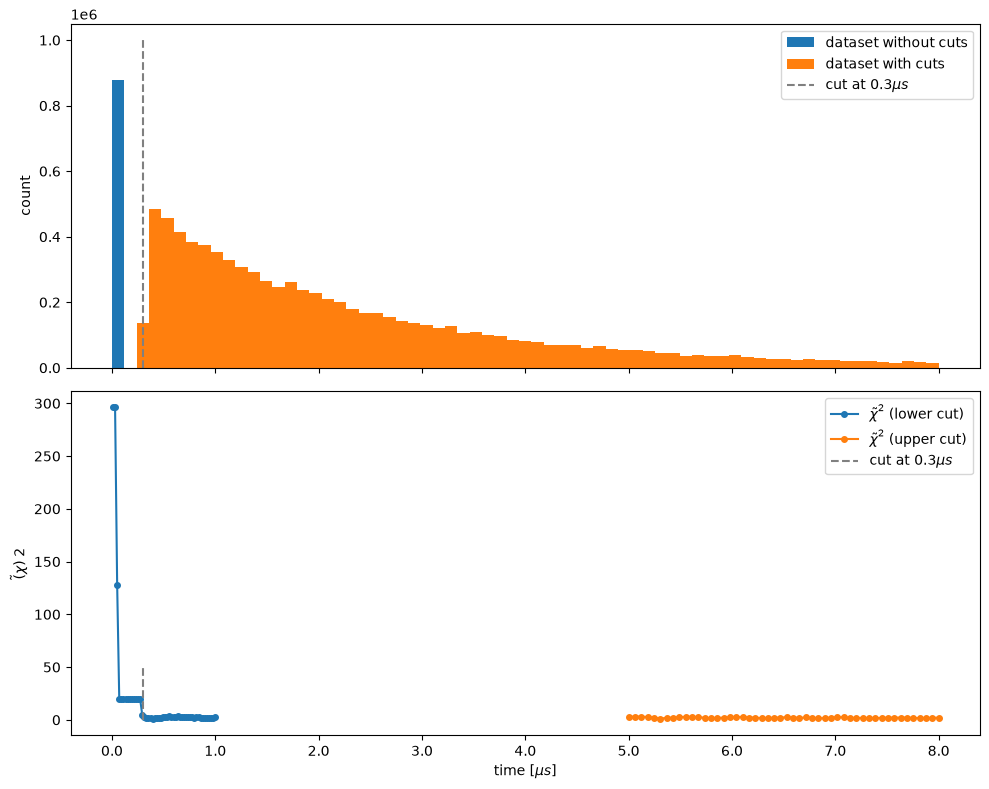

In [119]:
from plotly.subplots import make_subplots

edited_data = complete_pv[(complete_pv>0.25e-6) & (complete_pv<8e-6)]
full_data = complete_pv



print(len(pv_chiListIni) , len(pv_chiListEnd))

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].hist(full_data , bins=n_bins , range = (0,8e-6) , density = True , label = "dataset without cuts")
axes[0].hist(edited_data , bins=n_bins , range = (0,8e-6) , density = True, label = "dataset with cuts")


axes[1].plot(np.linspace(*start_cut_range), pv_chiListIni, "o-", label=r"$\tilde{\chi}^2$ (lower cut)", markersize=4)
axes[1].plot(np.linspace(*end_cut_range), pv_chiListEnd, "o-", label=r"$\tilde{\chi}^2$ (upper cut)", markersize=4)

axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x*1e6:.1f}'))
axes[1].set_xlabel("time $ [ \mu s] $")
axes[1].set_ylabel(r"$ \tilde(\chi)^ 2$")
axes[0].set_ylabel("count")
axes[0].vlines(0.3e-6, 0, 1e6, colors="gray", linestyle = "--", label="cut at $ 0.3 \mu s $")
axes[1].vlines(0.3e-6, 0, 50, colors="gray", linestyle = "--", label="cut at $ 0.3 \mu s $")

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.savefig("Photo/interpolation/pv_cuts.pdf" , format = "pdf")